# 事先预测模型：TabM 分离特征 + 固定超参数版

本 Notebook 参考两个已有 Notebook：

- `TabM_任务时间与能耗_分离特征v6(2).ipynb`：沿用其**时间/能耗分离特征、按时间顺序划分、缺失值处理原则、评价指标和可视化风格**；
- `事先预测模型.ipynb`：保留其中的**经验公式、线性回归、XGBoost、LightGBM、随机森林**。

本版的核心变化：

1. **任务时间与任务能耗使用两套不同特征**，与 TabM 当前实际运行的 14 + 14 个特征一致；
2. **取消 GridSearchCV / TimeSeriesSplit 网格搜索**，树模型直接使用固定超参数训练；
3. 时间、能耗分别按各自有效标签构造样本，并各自执行前 80% 训练、后 20% 测试；
4. 预测值统一截断到非负区间；
5. 指标与 TabM 一致：MAE、RMSE、R²、误差不超过 ±10% 的样本比例；
6. 对每个模型分别输出 TabM 风格的：真实值-预测值、残差、时序预测、误差分布、真实值分桶误差；经典模型没有 epoch 训练过程，因此不绘制 TabM 的训练损失曲线；
7. 额外输出五种模型的横向 RMSE / R² / Within10% 对比图。

> 固定超参数是在原 `事先预测模型.ipynb` 的参数范围基础上选择的一组偏稳健配置，并非重新网格搜索得到。若后续需要调整，只修改“固定超参数”单元即可。

## 1. 首次安装依赖

如环境尚未安装依赖，取消下一单元的注释并运行。

In [35]:
# %pip install -U numpy pandas scikit-learn joblib xgboost lightgbm matplotlib matplotlib-inline

## 2. 导入依赖与绘图配置

In [36]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
import re
import warnings
from pathlib import Path
from typing import Dict

import joblib
import numpy as np
import pandas as pd

from IPython.display import Image as IPythonImage
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import matplotlib
matplotlib.rcdefaults()
matplotlib.use("Agg")
import matplotlib.pyplot as plt
plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
    "text.color": "black",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Microsoft YaHei", "SimHei", "SimSun",
        "Microsoft YaHei UI", "DejaVu Sans",
    ],
    "axes.unicode_minus": False,
    "legend.facecolor": "white",
    "legend.edgecolor": "#888888",
    "legend.labelcolor": "black",
    "legend.framealpha": 1.0,
    "grid.alpha": 0.2,
    "grid.color": "#cccccc",
    "axes.grid": False,
    "axes.titlecolor": "black",
})

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("依赖导入完成。")

依赖导入完成。


## 3. 路径、TabM 分离特征与固定超参数

In [37]:
# =========================
# 1. 文件路径
# =========================
# 与 TabM Notebook 保持相同的项目目录推断方式。
NOTEBOOK_DIR = Path(globals().get("_dh", [Path.cwd()])[0]).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_FILE = PROJECT_ROOT / "data" / "任务特征和标签_20米_特征扩充.json"
OUTPUT_DIR = PROJECT_ROOT / "target" / "PreTaskModels_TabMFeatures_FixedParams"
PLOT_DIR = OUTPUT_DIR / "plots"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. TabM：任务时间 14 个特征
# =========================
TIME_FEATURE_COLS = [
    "straight_line_distance_m",
    "planned_total_distance_m",
    "planned_to_straight_distance_ratio",
    "endpoint_altitude_change_m",
    "planned_slope_mean",
    "planned_cumulative_ascent_m",
    "planned_cumulative_descent_m",
    "vehicle_recent10_duration_mean_sec",
    "vehicle_time_gap_since_prev_task_min",
    "vehicle_similar_top5_duration_mean_sec",
    "similar_top5_duration_mean_sec",
    "similar_top5_duration_std_sec",
    "similar_nearest_od_distance_m",
    "similar_nearest_time_gap_min",
    "vehicle_today_speed_mean_mps",
]

# =========================
# 3. TabM：任务能耗 14 个特征
# =========================
ENERGY_FEATURE_COLS = [
    "straight_line_distance_m",
    "planned_total_distance_m",
    "planned_to_straight_distance_ratio",
    "endpoint_altitude_change_m",
    "planned_slope_mean",
    "planned_cumulative_ascent_m",
    "planned_cumulative_descent_m",
    "vehicle_recent5_energy_mean_pct",
    "vehicle_time_gap_since_prev_task_min",
    "vehicle_similar_top5_energy_mean_pct",
    "similar_top5_energy_mean_pct",
    "similar_top5_energy_std_pct",
    "similar_nearest_od_distance_m",
    "similar_nearest_time_gap_min",
    "vehicle_today_speed_mean_mps",
]

TIME_TARGET = "task_duration_min"
ENERGY_TARGET = "total_energy_soc_delta_pct"
TEST_SIZE = 0.20
PLOT_DPI = 150
SAVE_MODELS = True

# =========================
# 4. 直接指定固定超参数
# =========================
# 线性回归不需要搜索超参数；保留截距并配合标准化。
LINEAR_PARAMS = {
    "fit_intercept": True,
}

# XGBoost：从旧 Notebook 的 FAST_MODE 参数范围中选取偏稳健组合。
XGB_PARAMS = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "n_estimators": 400,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "min_child_weight": 2,
    "reg_alpha": 0.10,
    "reg_lambda": 3.0,
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
}

# LightGBM：固定 400 棵树、较小学习率和 31 叶。
LGBM_PARAMS = {
    "objective": "regression",
    "n_estimators": 400,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_child_samples": 20,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.10,
    "reg_lambda": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
    "verbosity": -1,
    "importance_type": "gain",
}

# 随机森林：使用较多树降低方差，不做网格搜索。
RF_PARAMS = {
    "n_estimators": 500,
    "max_depth": 20,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": 0.80,
    "random_state": RANDOM_STATE,
    "n_jobs": 4,
}

FIXED_HYPERPARAMS = {
    "线性回归": LINEAR_PARAMS,
    "XGBoost": XGB_PARAMS,
    "LightGBM": LGBM_PARAMS,
    "随机森林": RF_PARAMS,
}

print("数据文件：", DATA_FILE)
print("输出目录：", OUTPUT_DIR)
print("时间模型特征数：", len(TIME_FEATURE_COLS))
print("能耗模型特征数：", len(ENERGY_FEATURE_COLS))
print("固定超参数：")
for name, params in FIXED_HYPERPARAMS.items():
    print(f"\n{name}")
    for key, value in params.items():
        print(f"  {key}: {value}")

数据文件： C:\Users\14993\PycharmProjects\BoLei-DataMining\data\任务特征和标签_20米_特征扩充.json
输出目录： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams
时间模型特征数： 15
能耗模型特征数： 15
固定超参数：

线性回归
  fit_intercept: True

XGBoost
  objective: reg:squarederror
  tree_method: hist
  n_estimators: 400
  max_depth: 3
  learning_rate: 0.05
  subsample: 0.9
  colsample_bytree: 0.9
  min_child_weight: 2
  reg_alpha: 0.1
  reg_lambda: 3.0
  random_state: 42
  n_jobs: 1

LightGBM
  objective: regression
  n_estimators: 400
  learning_rate: 0.05
  num_leaves: 31
  min_child_samples: 20
  subsample: 0.9
  colsample_bytree: 0.9
  reg_alpha: 0.1
  reg_lambda: 1.0
  random_state: 42
  n_jobs: 1
  verbosity: -1
  importance_type: gain

随机森林
  n_estimators: 500
  max_depth: 20
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.8
  random_state: 42
  n_jobs: 4


## 4. 读取与清洗数据（与 TabM 分离特征版一致）

In [38]:
def load_task_dataset(json_path: Path) -> pd.DataFrame:
    if not json_path.exists():
        raise FileNotFoundError(f"数据文件不存在：{json_path}")

    with json_path.open("r", encoding="utf-8-sig") as file:
        raw = json.load(file)

    if not isinstance(raw, list):
        raise ValueError("JSON 顶层必须是任务数组")

    df = pd.DataFrame(raw)

    all_feature_cols = list(dict.fromkeys(TIME_FEATURE_COLS + ENERGY_FEATURE_COLS))
    required = {
        "task_id", "actual_start_time", "actual_end_time",
        TIME_TARGET, ENERGY_TARGET, *all_feature_cols,
    }
    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError("JSON 缺少以下字段：\n" + "\n".join(missing))

    df["actual_start_time"] = pd.to_datetime(df["actual_start_time"], format="mixed", errors="coerce")
    df["actual_end_time"] = pd.to_datetime(df["actual_end_time"], format="mixed", errors="coerce")

    numeric_cols = list(dict.fromkeys(all_feature_cols + [TIME_TARGET, ENERGY_TARGET]))
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    initial_count = len(df)
    df = df.dropna(subset=["task_id", "actual_start_time"])
    df = df.drop_duplicates(subset="task_id", keep="first")
    df = df.sort_values(
        ["actual_start_time", "actual_end_time", "task_id"]
    ).reset_index(drop=True)

    # 与 TabM 一致：当前任务自身的核心路线/地形字段要求有效；
    # 历史统计允许为空，后续只用训练集的中位数填补。
    required_current_features = [
        "planned_total_distance_m",
        "endpoint_altitude_change_m",
        "planned_slope_mean",
        "planned_cumulative_ascent_m",
    ]
    df = df.dropna(subset=required_current_features).copy()

    print("原始任务数：", initial_count)
    print("基础清洗后任务数：", len(df))
    print("时间范围：", df["actual_start_time"].min(), "至", df["actual_start_time"].max())
    return df


df = load_task_dataset(DATA_FILE)

# 时间和能耗分别构造可训练数据，避免一个目标缺失时误删另一个目标的样本。
time_df = df.dropna(subset=[TIME_TARGET]).copy()
time_df = time_df[time_df[TIME_TARGET] >= 0].reset_index(drop=True)

energy_df = df.dropna(subset=[ENERGY_TARGET]).copy()
energy_df = energy_df[energy_df[ENERGY_TARGET] >= 0].reset_index(drop=True)

print("\n时间模型可用样本数：", len(time_df))
print("能耗模型可用样本数：", len(energy_df))

print("\n时间特征缺失率最高的 10 项：")
display(
    time_df[TIME_FEATURE_COLS]
    .isna().mean().sort_values(ascending=False)
    .head(10).to_frame("missing_ratio")
)

print("能耗特征缺失率最高的 10 项：")
display(
    energy_df[ENERGY_FEATURE_COLS]
    .isna().mean().sort_values(ascending=False)
    .head(10).to_frame("missing_ratio")
)

原始任务数： 3210
基础清洗后任务数： 3210
时间范围： 2026-06-08 00:01:03.574000 至 2026-07-07 23:03:05.110000

时间模型可用样本数： 3210
能耗模型可用样本数： 3210

时间特征缺失率最高的 10 项：


,missing_ratio
vehicle_today_speed_mean_mps,0.065421
vehicle_recent10_duration_mean_sec,0.003115
vehicle_similar_top5_duration_mean_sec,0.003115
vehicle_time_gap_since_prev_task_min,0.003115
similar_nearest_od_distance_m,0.000935
similar_top5_duration_std_sec,0.000935
similar_top5_duration_mean_sec,0.000935
similar_nearest_time_gap_min,0.000935
planned_cumulative_descent_m,0.000000
planned_slope_mean,0.000000


能耗特征缺失率最高的 10 项：


,missing_ratio
vehicle_today_speed_mean_mps,0.065421
vehicle_recent5_energy_mean_pct,0.003115
vehicle_similar_top5_energy_mean_pct,0.003115
vehicle_time_gap_since_prev_task_min,0.003115
similar_nearest_od_distance_m,0.000935
similar_top5_energy_std_pct,0.000935
similar_top5_energy_mean_pct,0.000935
similar_nearest_time_gap_min,0.000935
planned_cumulative_descent_m,0.000000
planned_slope_mean,0.000000


## 5. 按时间顺序分别划分时间模型和能耗模型训练/测试集

In [39]:
def chronological_split(target_df: pd.DataFrame, test_size: float = TEST_SIZE):
    test_start = int(len(target_df) * (1.0 - test_size))
    train_df = target_df.iloc[:test_start].copy()
    test_df = target_df.iloc[test_start:].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        raise ValueError("训练集或测试集为空，请检查样本量和 TEST_SIZE")

    assert train_df["actual_start_time"].max() <= test_df["actual_start_time"].min()
    return train_df, test_df


time_train_df, time_test_df = chronological_split(time_df)
energy_train_df, energy_test_df = chronological_split(energy_df)

X_time_train = time_train_df[TIME_FEATURE_COLS].copy()
X_time_test = time_test_df[TIME_FEATURE_COLS].copy()
y_time_train = time_train_df[TIME_TARGET].astype(float).copy()
y_time_test = time_test_df[TIME_TARGET].astype(float).copy()

X_energy_train = energy_train_df[ENERGY_FEATURE_COLS].copy()
X_energy_test = energy_test_df[ENERGY_FEATURE_COLS].copy()
y_energy_train = energy_train_df[ENERGY_TARGET].astype(float).copy()
y_energy_test = energy_test_df[ENERGY_TARGET].astype(float).copy()

print("任务时间：")
print("  训练集：", len(time_train_df), time_train_df["actual_start_time"].min(), "至", time_train_df["actual_start_time"].max())
print("  测试集：", len(time_test_df), time_test_df["actual_start_time"].min(), "至", time_test_df["actual_start_time"].max())
print("\n任务能耗：")
print("  训练集：", len(energy_train_df), energy_train_df["actual_start_time"].min(), "至", energy_train_df["actual_start_time"].max())
print("  测试集：", len(energy_test_df), energy_test_df["actual_start_time"].min(), "至", energy_test_df["actual_start_time"].max())

任务时间：
  训练集： 2568 2026-06-08 00:01:03.574000 至 2026-07-04 06:44:29.044000
  测试集： 642 2026-07-04 06:51:01.122000 至 2026-07-07 23:03:05.110000

任务能耗：
  训练集： 2568 2026-06-08 00:01:03.574000 至 2026-07-04 06:44:29.044000
  测试集： 642 2026-07-04 06:51:01.122000 至 2026-07-07 23:03:05.110000


## 6. 公共评价与模型流水线

In [40]:
def regression_metrics(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rel_err = np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), 1e-8)
    within_10pct = float(np.mean(rel_err <= 0.10))
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "R2": float(r2_score(y_true, y_pred)),
        "Within10%": within_10pct,
    }


def make_linear_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression(**LINEAR_PARAMS)),
    ])


def make_tree_pipeline(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("model", estimator),
    ])


def fit_model_pair(model_name, base_estimator=None, linear=False):
    """使用 TabM 的两套分离特征分别训练时间/能耗模型。"""
    if linear:
        time_model = make_linear_pipeline()
        energy_model = make_linear_pipeline()
    else:
        time_model = make_tree_pipeline(clone(base_estimator))
        energy_model = make_tree_pipeline(clone(base_estimator))

    print("=" * 80)
    print(f"训练 {model_name}：任务时间")
    time_model.fit(X_time_train, y_time_train)
    print(f"训练 {model_name}：任务能耗")
    energy_model.fit(X_energy_train, y_energy_train)

    # 与 TabM 一样，时间与 SOC 能耗都截断到非负值。
    time_pred = np.maximum(time_model.predict(X_time_test), 0.0)
    energy_pred = np.maximum(energy_model.predict(X_energy_test), 0.0)

    return {
        "time_model": time_model,
        "energy_model": energy_model,
        "time_pred": time_pred,
        "energy_pred": energy_pred,
        "time_metrics": regression_metrics(y_time_test, time_pred),
        "energy_metrics": regression_metrics(y_energy_test, energy_pred),
    }


model_results = {}

## 7. 经验公式：规划距离比例

沿用原 `事先预测模型.ipynb` 的经验公式：在训练集上拟合无截距比例系数

\[
\hat y = k \cdot d, \qquad
k = \frac{\sum_i d_i y_i}{\sum_i d_i^2}
\]

其中 `d = planned_total_distance_m`。由于时间与能耗样本现在分别构造，因此两个比例系数也分别只使用各自训练集拟合。

In [41]:
def fit_distance_ratio_baseline(train_df, test_df, target_col):
    distance_train = train_df["planned_total_distance_m"].to_numpy(dtype=float)
    distance_test = test_df["planned_total_distance_m"].to_numpy(dtype=float)
    y_train = train_df[target_col].to_numpy(dtype=float)

    denominator = float(np.sum(distance_train ** 2))
    if denominator <= 0:
        raise ValueError("训练集规划总距离无效，无法拟合经验公式。")

    k = float(np.sum(distance_train * y_train) / denominator)
    prediction = np.maximum(k * distance_test, 0.0)
    return k, prediction


baseline_time_k, baseline_time_pred = fit_distance_ratio_baseline(
    time_train_df, time_test_df, TIME_TARGET
)
baseline_energy_k, baseline_energy_pred = fit_distance_ratio_baseline(
    energy_train_df, energy_test_df, ENERGY_TARGET
)

model_results["经验公式（规划距离比例）"] = {
    "time_model": None,
    "energy_model": None,
    "time_pred": baseline_time_pred,
    "energy_pred": baseline_energy_pred,
    "time_metrics": regression_metrics(y_time_test, baseline_time_pred),
    "energy_metrics": regression_metrics(y_energy_test, baseline_energy_pred),
}

print(f"时间比例系数：{baseline_time_k:.8f} 分钟/米")
print(f"能耗比例系数：{baseline_energy_k:.8f} SOC百分点/米")
display(pd.DataFrame(
    [
        model_results["经验公式（规划距离比例）"]["time_metrics"],
        model_results["经验公式（规划距离比例）"]["energy_metrics"],
    ],
    index=["任务时间", "任务能耗"],
).round(4))

时间比例系数：0.00469929 分钟/米
能耗比例系数：0.00378854 SOC百分点/米


,MAE,RMSE,R2,Within10%
任务时间,1.1278,1.5037,0.7423,0.8396
任务能耗,1.4988,1.7999,0.6427,0.5109


## 8. 线性回归：固定配置直接训练

In [42]:
model_results["线性回归"] = fit_model_pair(
    "线性回归",
    linear=True,
)

display(pd.DataFrame(
    [model_results["线性回归"]["time_metrics"], model_results["线性回归"]["energy_metrics"]],
    index=["任务时间", "任务能耗"],
).round(4))

训练 线性回归：任务时间
训练 线性回归：任务能耗


,MAE,RMSE,R2,Within10%
任务时间,0.5488,0.9148,0.9046,0.9688
任务能耗,0.6065,0.7813,0.9327,0.9315


## 9. XGBoost：固定超参数直接训练

In [43]:
xgb_base = XGBRegressor(**XGB_PARAMS)
model_results["XGBoost"] = fit_model_pair(
    "XGBoost",
    base_estimator=xgb_base,
)

display(pd.DataFrame(
    [model_results["XGBoost"]["time_metrics"], model_results["XGBoost"]["energy_metrics"]],
    index=["任务时间", "任务能耗"],
).round(4))

训练 XGBoost：任务时间
训练 XGBoost：任务能耗


,MAE,RMSE,R2,Within10%
任务时间,0.5949,0.9433,0.8986,0.9642
任务能耗,0.6154,0.7948,0.9303,0.9190


## 10. LightGBM：固定超参数直接训练

In [44]:
lgbm_base = LGBMRegressor(**LGBM_PARAMS)
model_results["LightGBM"] = fit_model_pair(
    "LightGBM",
    base_estimator=lgbm_base,
)

display(pd.DataFrame(
    [model_results["LightGBM"]["time_metrics"], model_results["LightGBM"]["energy_metrics"]],
    index=["任务时间", "任务能耗"],
).round(4))

训练 LightGBM：任务时间
训练 LightGBM：任务能耗


C:\Users\14993\PycharmProjects\BoLei-DataMining\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\14993\PycharmProjects\BoLei-DataMining\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2,Within10%
任务时间,0.6091,0.9523,0.8967,0.9673
任务能耗,0.6315,0.8022,0.9290,0.9143


## 11. 随机森林：固定超参数直接训练

In [45]:
rf_base = RandomForestRegressor(**RF_PARAMS)
model_results["随机森林"] = fit_model_pair(
    "随机森林",
    base_estimator=rf_base,
)

display(pd.DataFrame(
    [model_results["随机森林"]["time_metrics"], model_results["随机森林"]["energy_metrics"]],
    index=["任务时间", "任务能耗"],
).round(4))

训练 随机森林：任务时间
训练 随机森林：任务能耗


,MAE,RMSE,R2,Within10%
任务时间,0.6109,0.9501,0.8971,0.9579
任务能耗,0.6097,0.7968,0.9300,0.9112


## 12. 测试集统一指标比较

In [46]:
time_comparison = pd.DataFrame([
    {"model": model_name, **result["time_metrics"]}
    for model_name, result in model_results.items()
]).set_index("model").sort_values("RMSE")

energy_comparison = pd.DataFrame([
    {"model": model_name, **result["energy_metrics"]}
    for model_name, result in model_results.items()
]).set_index("model").sort_values("RMSE")

print("任务时间测试集指标（分钟）：")
display(time_comparison.round(4))

print("任务能耗测试集指标（SOC 百分点）：")
display(energy_comparison.round(4))

print("任务时间最佳模型：", time_comparison.index[0])
print("任务能耗最佳模型：", energy_comparison.index[0])

任务时间测试集指标（分钟）：


,MAE,RMSE,R2,Within10%
model,,,,
线性回归,0.5488,0.9148,0.9046,0.9688
XGBoost,0.5949,0.9433,0.8986,0.9642
随机森林,0.6109,0.9501,0.8971,0.9579
LightGBM,0.6091,0.9523,0.8967,0.9673
经验公式（规划距离比例）,1.1278,1.5037,0.7423,0.8396


任务能耗测试集指标（SOC 百分点）：


,MAE,RMSE,R2,Within10%
model,,,,
线性回归,0.6065,0.7813,0.9327,0.9315
XGBoost,0.6154,0.7948,0.9303,0.9190
随机森林,0.6097,0.7968,0.9300,0.9112
LightGBM,0.6315,0.8022,0.9290,0.9143
经验公式（规划距离比例）,1.4988,1.7999,0.6427,0.5109


任务时间最佳模型： 线性回归
任务能耗最佳模型： 线性回归


## 13. TabM 风格绘图函数

In [47]:
def safe_filename(title: str) -> str:
    name = re.sub(r"[^0-9A-Za-z一-鿿_-]+", "_", title).strip("_")
    return (name or "plot")[:120] + ".png"


def save_and_display(fig, title: str) -> None:
    path = PLOT_DIR / safe_filename(title)
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.close(fig)
    display(IPythonImage(filename=str(path)))
    print("已保存：", path)


def plot_actual_vs_predicted(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    lower = float(min(y_true.min(), y_pred.min()))
    upper = float(max(y_true.max(), y_pred.max()))
    padding = max((upper - lower) * 0.05, 1e-6)

    fig, ax = plt.subplots(figsize=(7.2, 5.5))
    ax.scatter(y_true, y_pred, s=28, alpha=0.65)
    ax.plot(
        [lower - padding, upper + padding],
        [lower - padding, upper + padding],
        linestyle="--",
        linewidth=1.3,
    )
    ax.set_xlim(lower - padding, upper + padding)
    ax.set_ylim(lower - padding, upper + padding)
    ax.set_xlabel(f"真实值（{unit}）")
    ax.set_ylabel(f"预测值（{unit}）")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_residuals(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_true - y_pred

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.scatter(y_pred, residual, s=28, alpha=0.65)
    ax.axhline(0.0, linestyle="--", linewidth=1.3)
    ax.set_xlabel(f"预测值（{unit}）")
    ax.set_ylabel(f"残差：真实值 - 预测值（{unit}）")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_prediction_sequence(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    index = np.arange(len(y_true))

    fig, ax = plt.subplots(figsize=(12.0, 4.8))
    ax.plot(index, y_true, linewidth=1.2, label="真实值")
    ax.plot(index, y_pred, linewidth=1.2, label="预测值")
    ax.set_xlabel("按任务开始时间排序后的测试集序号")
    ax.set_ylabel(unit)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_error_distribution(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    errors = y_true - y_pred

    fig, ax = plt.subplots(figsize=(7.0, 4.8))
    ax.hist(errors, bins=60, alpha=0.75, edgecolor="white")
    ax.axvline(0.0, linestyle="--", linewidth=1.3, label="零误差线")
    ax.axvline(errors.mean(), linestyle="--", linewidth=1.2,
               label=f"均值 = {errors.mean():.2f} {unit}")
    ax.axvline(np.median(errors), linestyle=":", linewidth=1.2,
               label=f"中位数 = {np.median(errors):.2f} {unit}")
    ax.set_xlabel(f"误差（真实 - 预测）[{unit}]")
    ax.set_ylabel("样本数")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_error_by_true_value_bins(y_true, y_pred, title: str, unit: str, n_bins: int = 8) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_err = np.abs(y_true - y_pred)

    unique_count = int(pd.Series(y_true).nunique())
    if unique_count < 2:
        print(f"跳过分桶图（真实值唯一值不足 2 个）：{title}")
        return

    q = min(n_bins, unique_count)
    df_tmp = pd.DataFrame({"true": y_true, "abs_err": abs_err})
    df_tmp["bin"] = pd.qcut(df_tmp["true"], q=q, duplicates="drop")
    grouped = df_tmp.groupby("bin", observed=False).agg(
        count=("true", "size"),
        mean_true=("true", "mean"),
        mean_abs_err=("abs_err", "mean"),
    )
    grouped["mape"] = (
        grouped["mean_abs_err"] / np.maximum(np.abs(grouped["mean_true"]), 1e-8) * 100
    ).round(2)

    fig, ax1 = plt.subplots(figsize=(9.0, 4.8))
    x = np.arange(len(grouped))
    width = 0.35
    ax1.bar(x - width / 2, grouped["count"], width=width, alpha=0.8, label="样本数")
    ax1.set_xlabel("真实值分桶（分位数）")
    ax1.set_ylabel("样本数")

    ax2 = ax1.twinx()
    ax2.plot(x, grouped["mape"], marker="o", linewidth=1.8, label="桶内 MAPE (%)")
    ax2.set_ylabel("MAPE (%)")

    ax1.set_xticks(x)
    ax1.set_xticklabels(
        [f"{interval.left:.1f}-{interval.right:.1f}{unit}" for interval in grouped.index],
        rotation=25,
    )
    ax1.set_title(title)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    ax1.grid(alpha=0.2, axis="y")
    fig.tight_layout()
    save_and_display(fig, title)


def plot_one_model_tabm_style(model_name: str, result: dict) -> None:
    # 时间：5 张
    plot_actual_vs_predicted(
        y_time_test, result["time_pred"], f"{model_name}_任务时间_真实值与预测值", "分钟"
    )
    plot_residuals(
        y_time_test, result["time_pred"], f"{model_name}_任务时间_残差图", "分钟"
    )
    plot_prediction_sequence(
        y_time_test, result["time_pred"], f"{model_name}_任务时间_测试集时序预测", "分钟"
    )
    plot_error_distribution(
        y_time_test, result["time_pred"], f"{model_name}_任务时间_误差分布", "分钟"
    )
    plot_error_by_true_value_bins(
        y_time_test, result["time_pred"], f"{model_name}_任务时间_分桶误差", "分钟"
    )

    # 能耗：5 张
    plot_actual_vs_predicted(
        y_energy_test, result["energy_pred"], f"{model_name}_任务能耗_真实值与预测值", "SOC百分点"
    )
    plot_residuals(
        y_energy_test, result["energy_pred"], f"{model_name}_任务能耗_残差图", "SOC百分点"
    )
    plot_prediction_sequence(
        y_energy_test, result["energy_pred"], f"{model_name}_任务能耗_测试集时序预测", "SOC百分点"
    )
    plot_error_distribution(
        y_energy_test, result["energy_pred"], f"{model_name}_任务能耗_误差分布", "SOC百分点"
    )
    plot_error_by_true_value_bins(
        y_energy_test, result["energy_pred"], f"{model_name}_任务能耗_分桶误差", "SOC百分点"
    )

## 14. 为五种模型输出 TabM 风格详细图


绘图： 经验公式（规划距离比例）


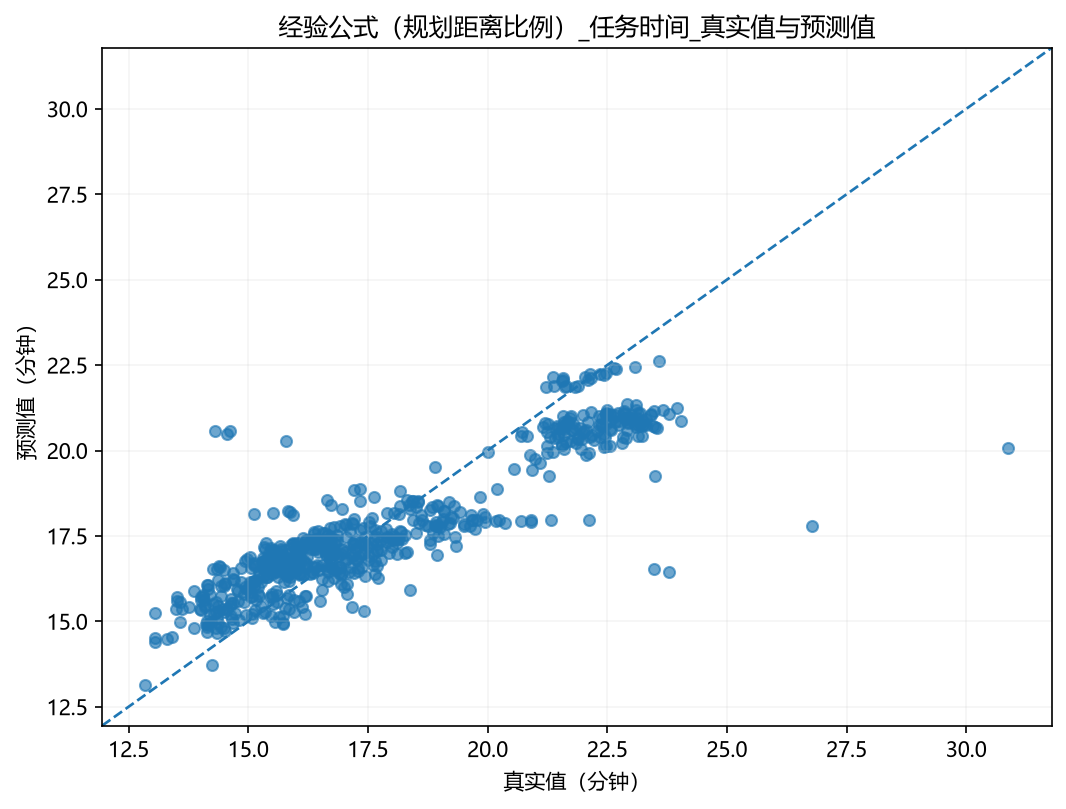

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务时间_真实值与预测值.png


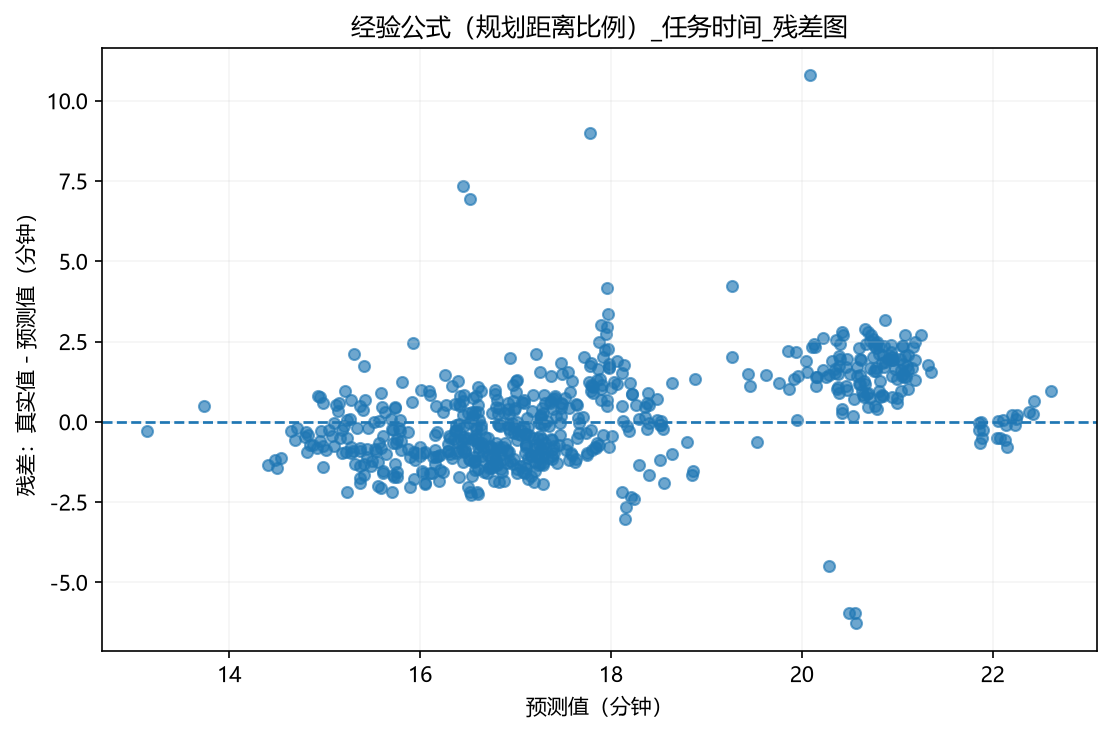

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务时间_残差图.png


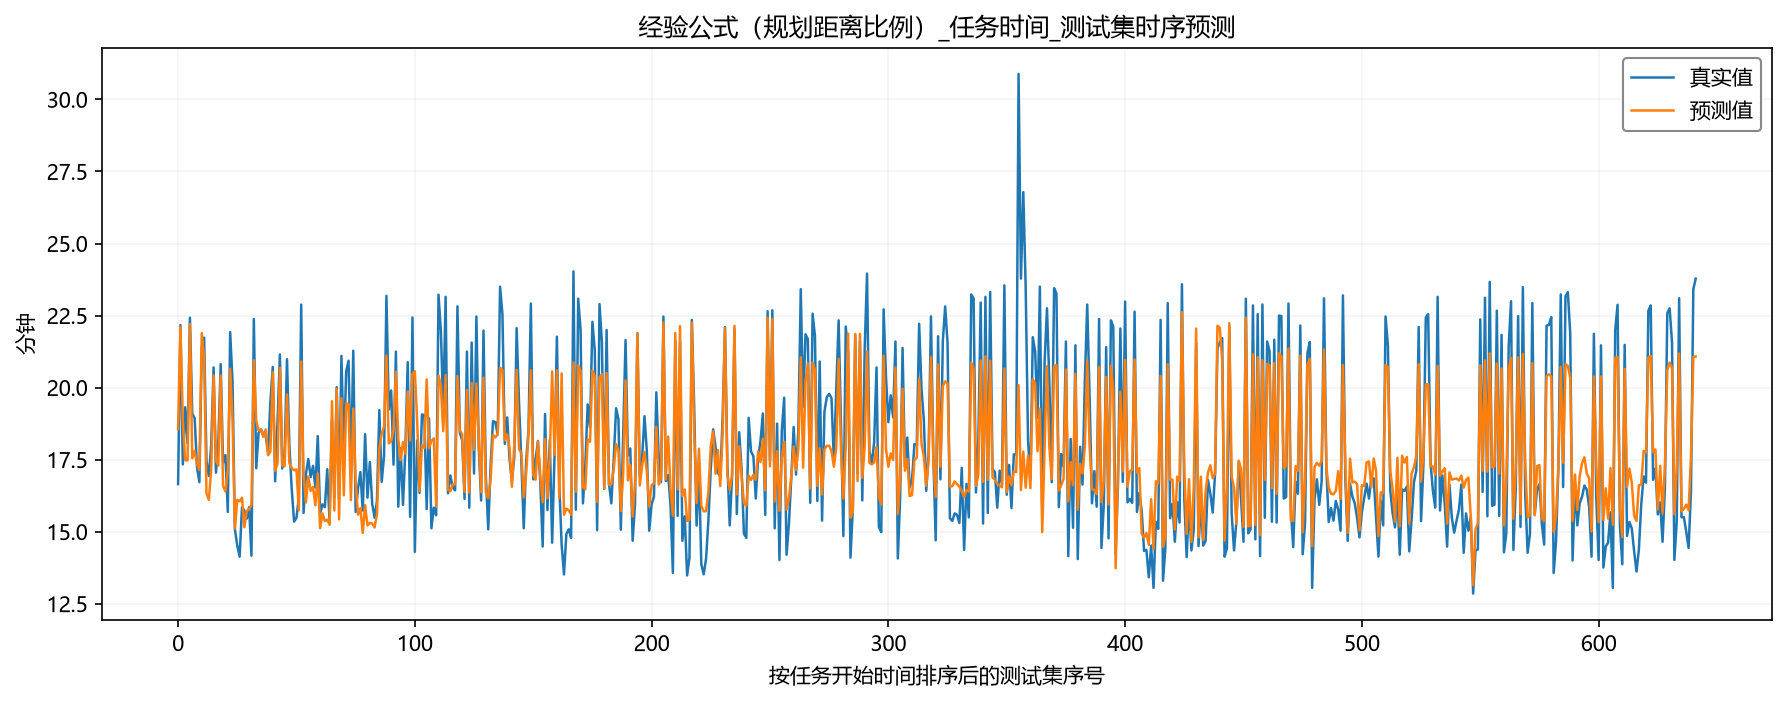

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务时间_测试集时序预测.png


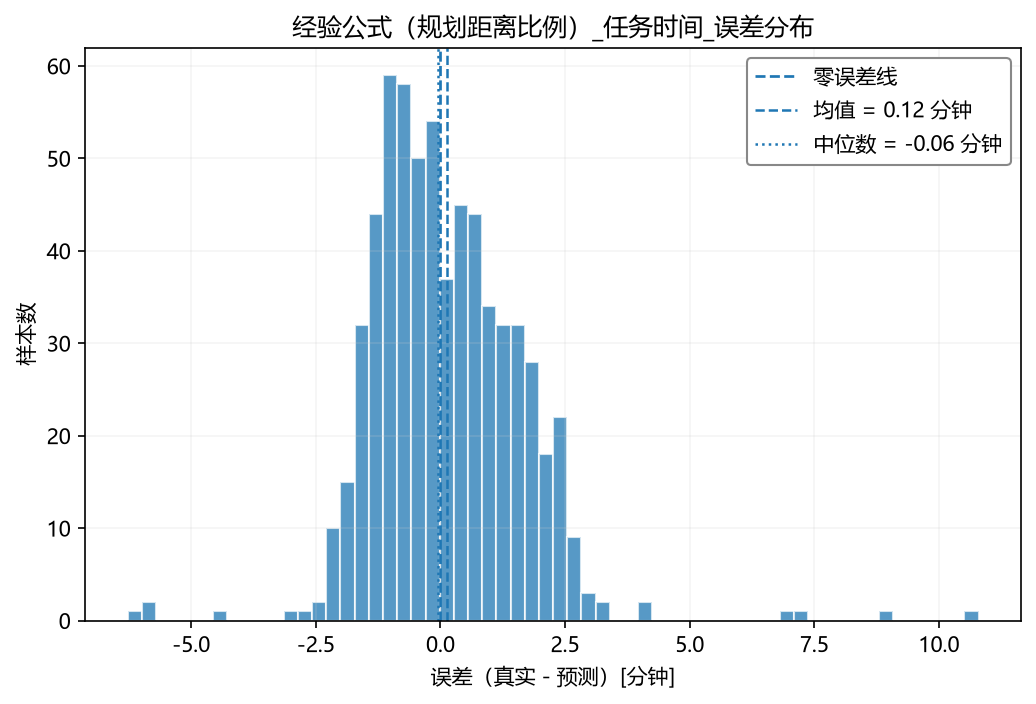

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务时间_误差分布.png


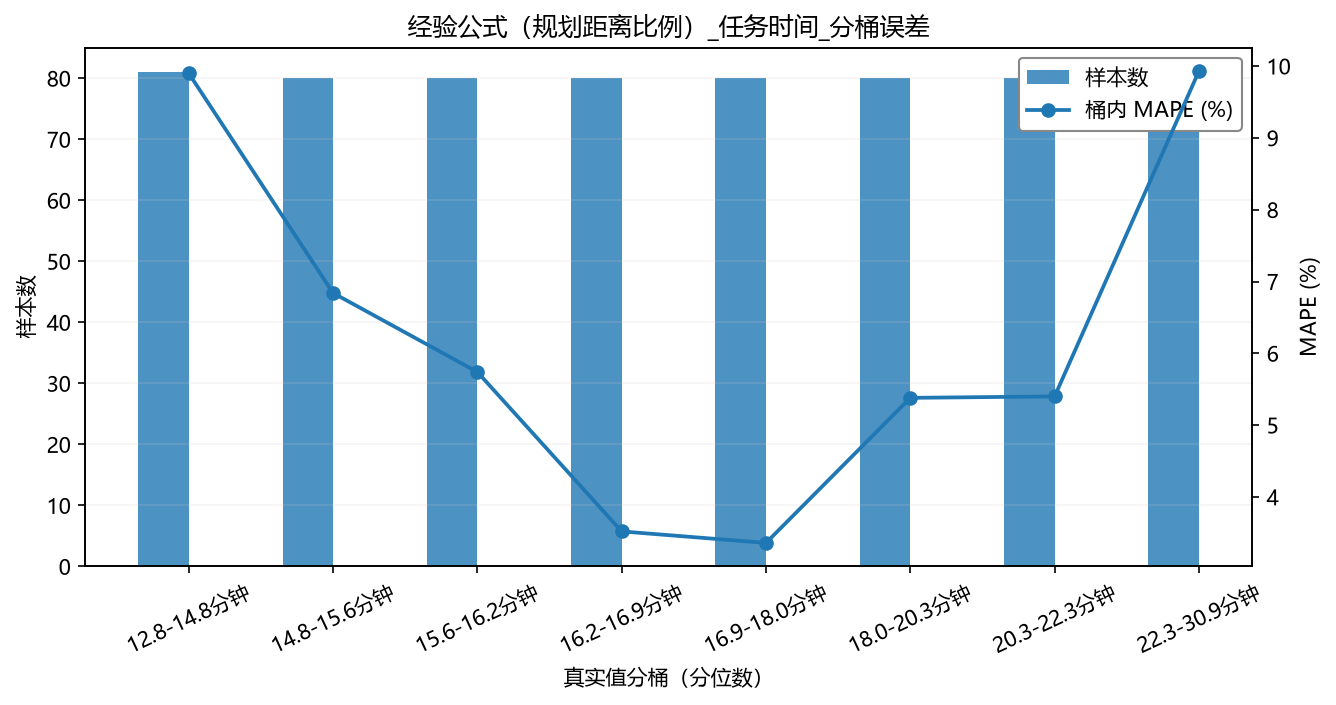

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务时间_分桶误差.png


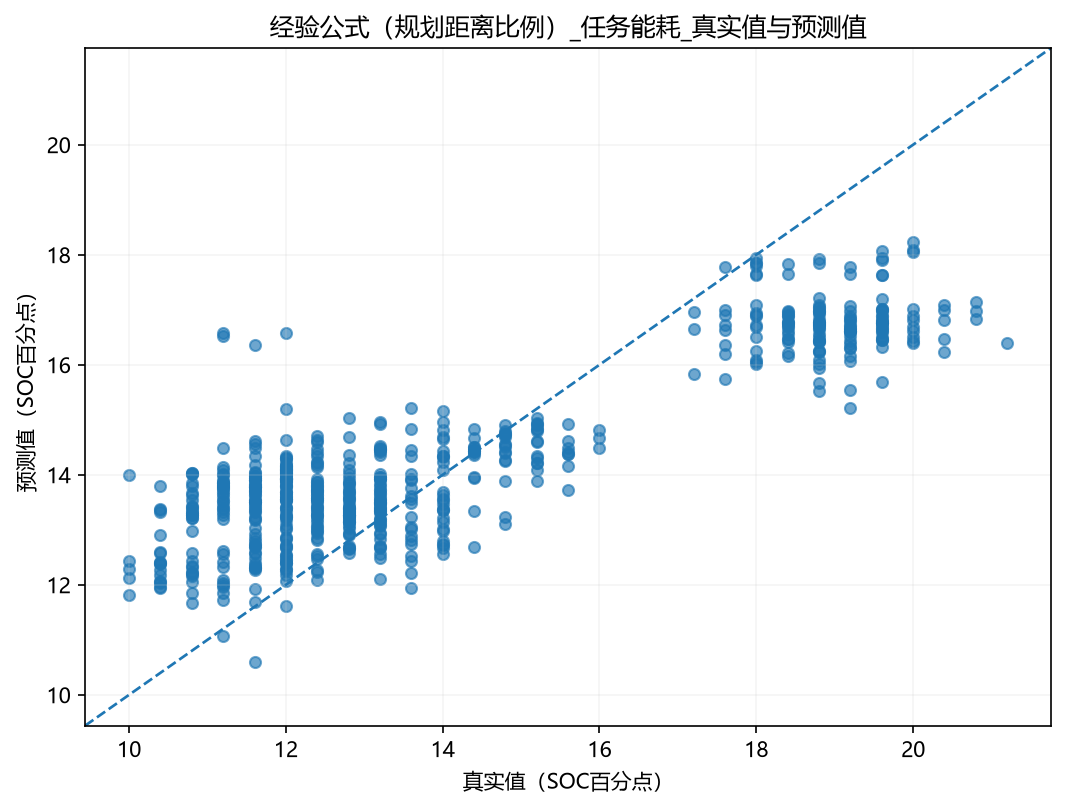

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务能耗_真实值与预测值.png


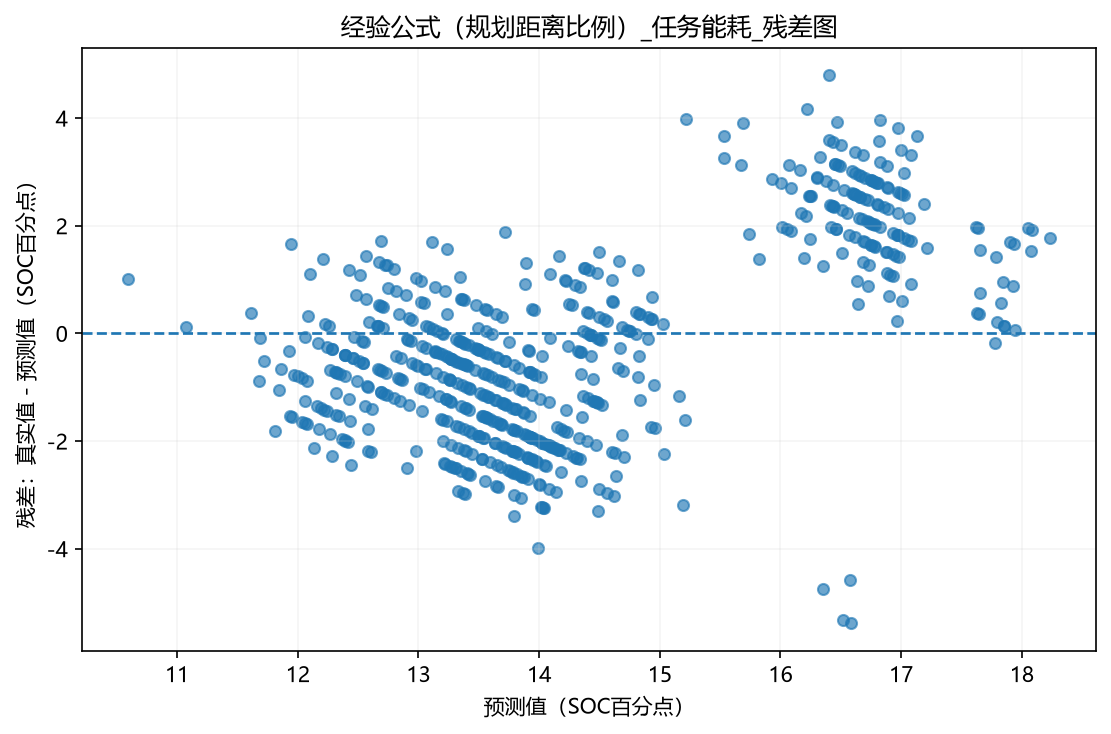

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务能耗_残差图.png


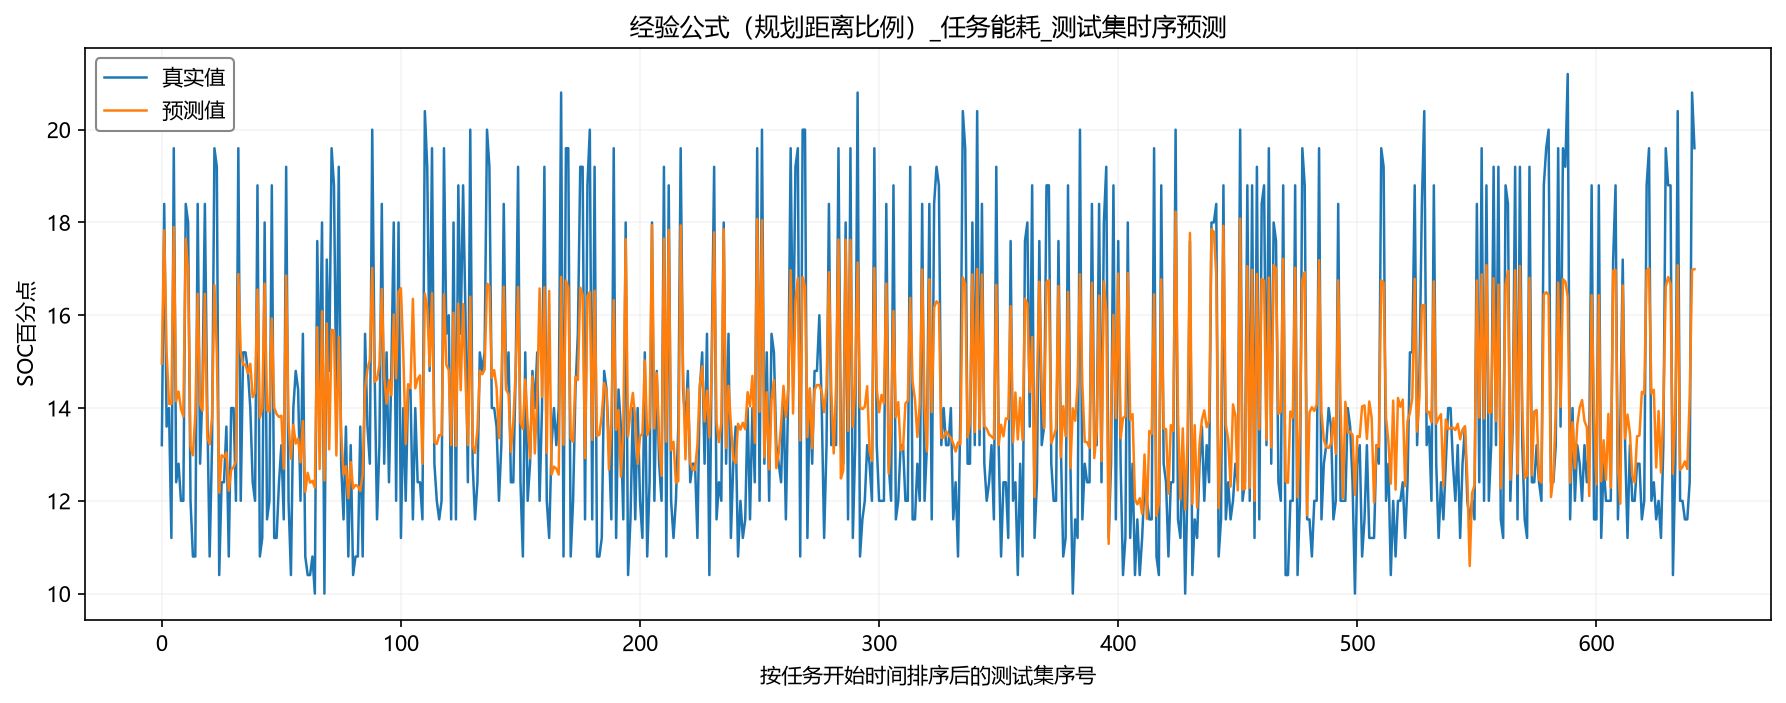

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务能耗_测试集时序预测.png


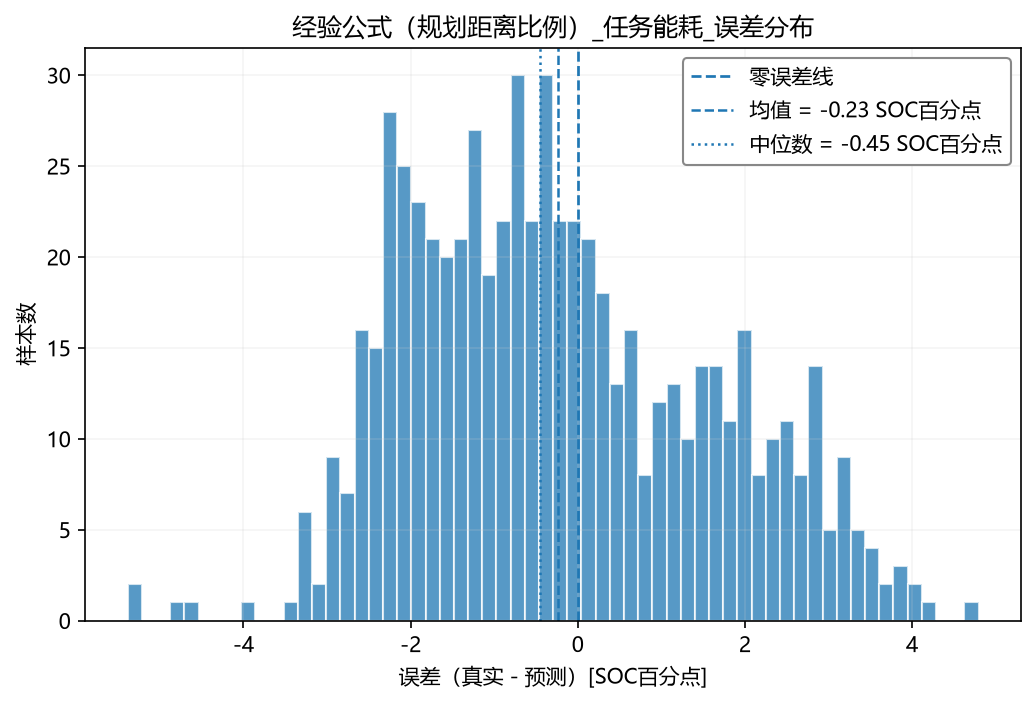

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务能耗_误差分布.png


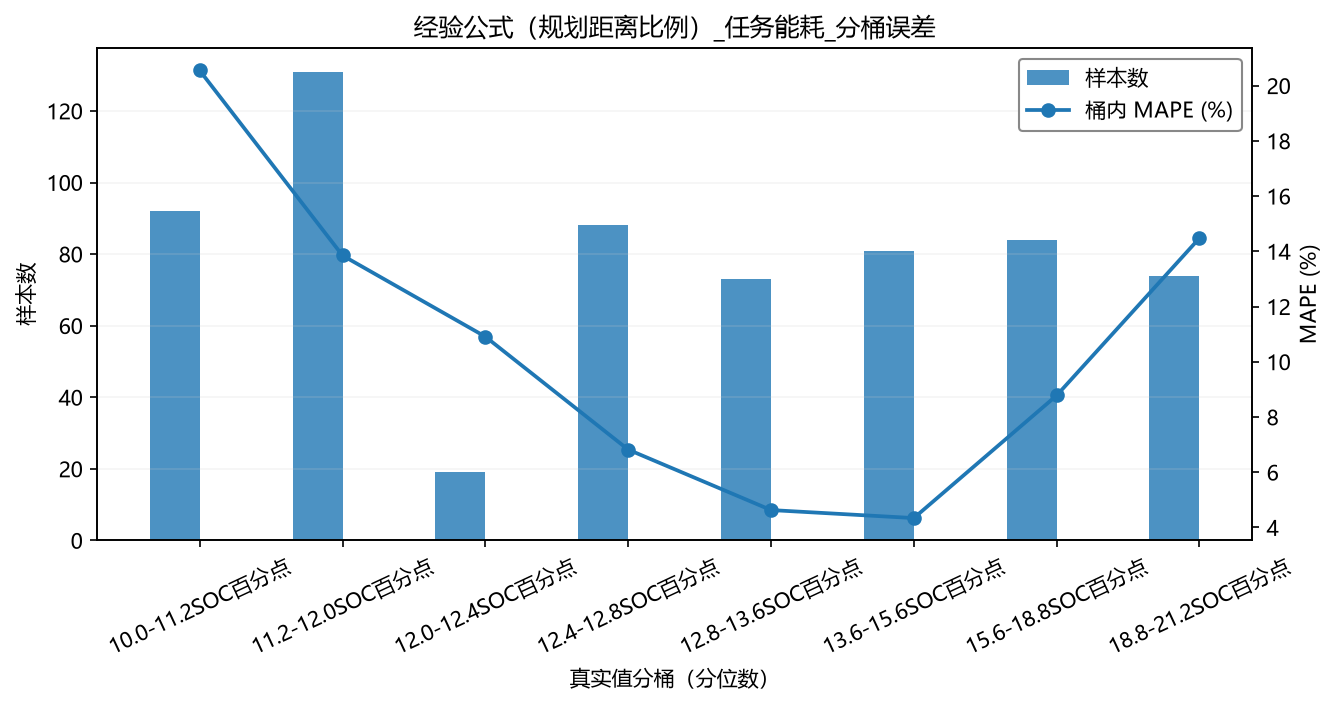

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\经验公式_规划距离比例__任务能耗_分桶误差.png

绘图： 线性回归


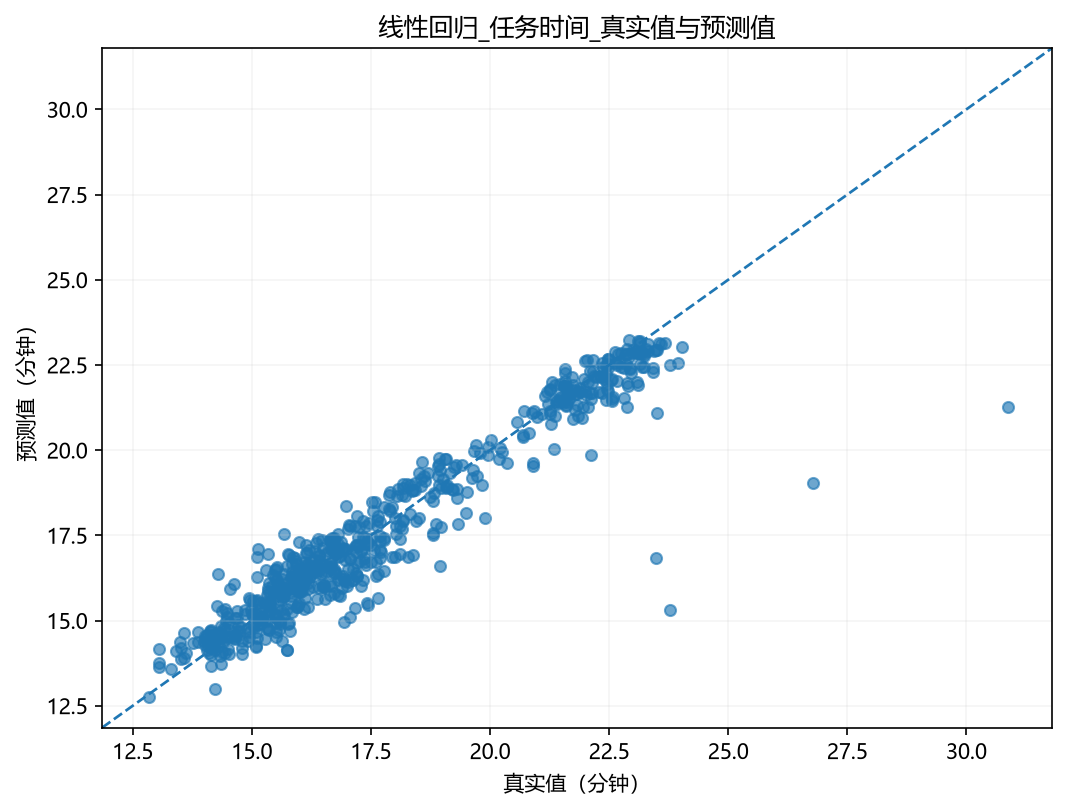

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务时间_真实值与预测值.png


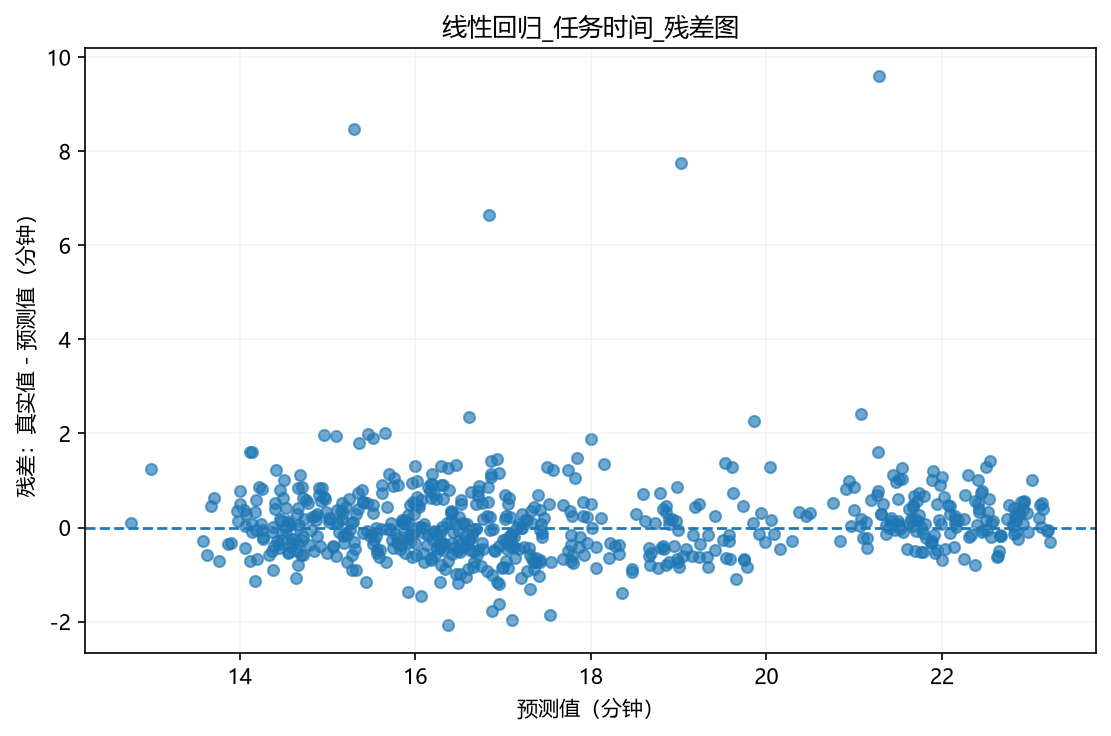

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务时间_残差图.png


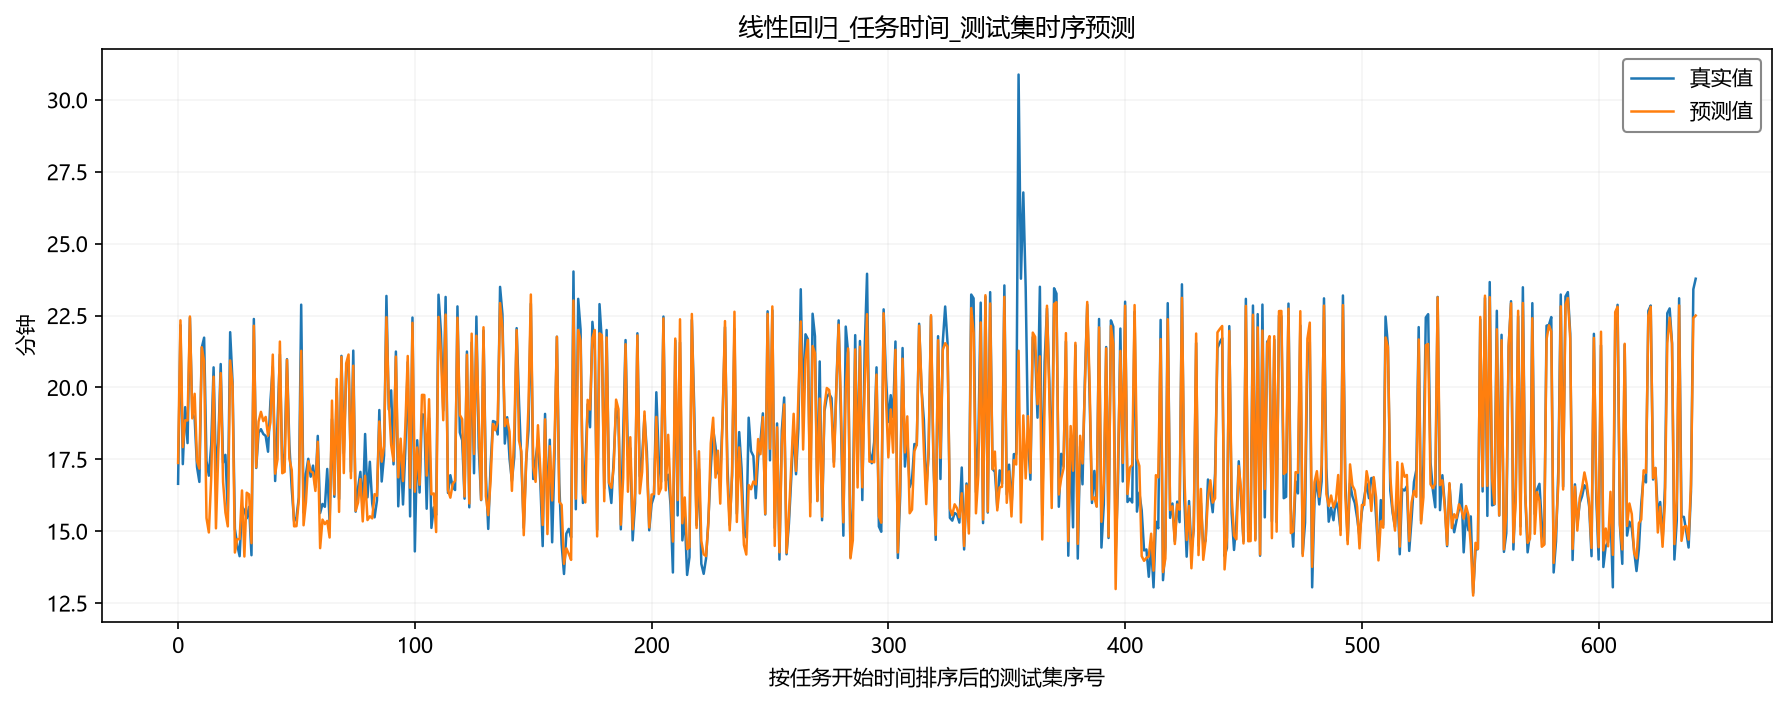

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务时间_测试集时序预测.png


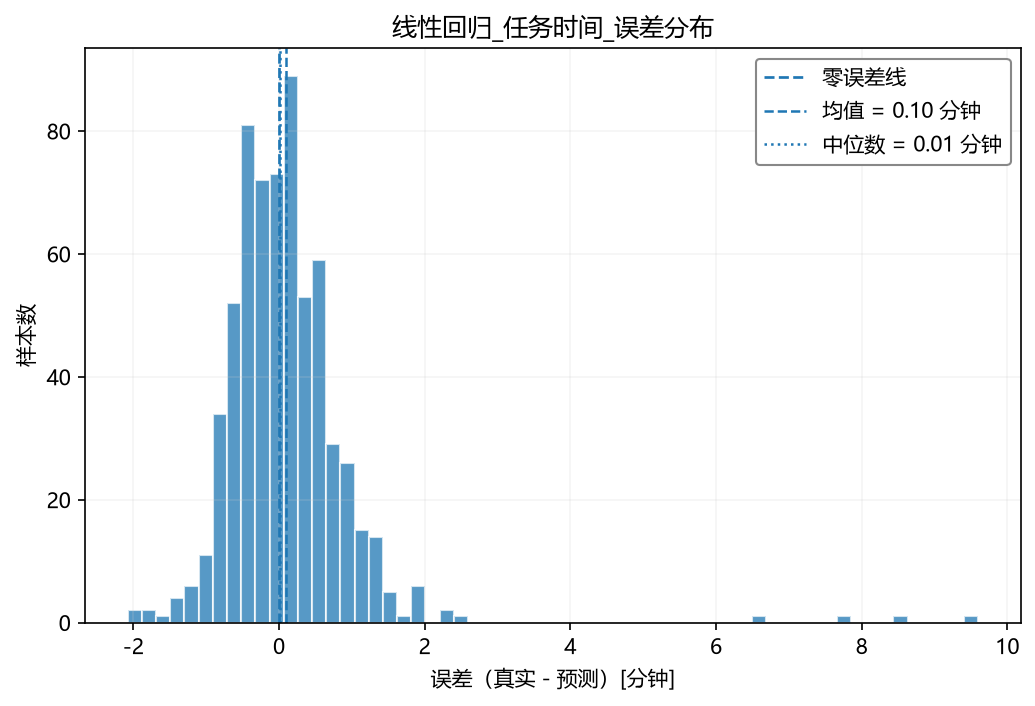

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务时间_误差分布.png


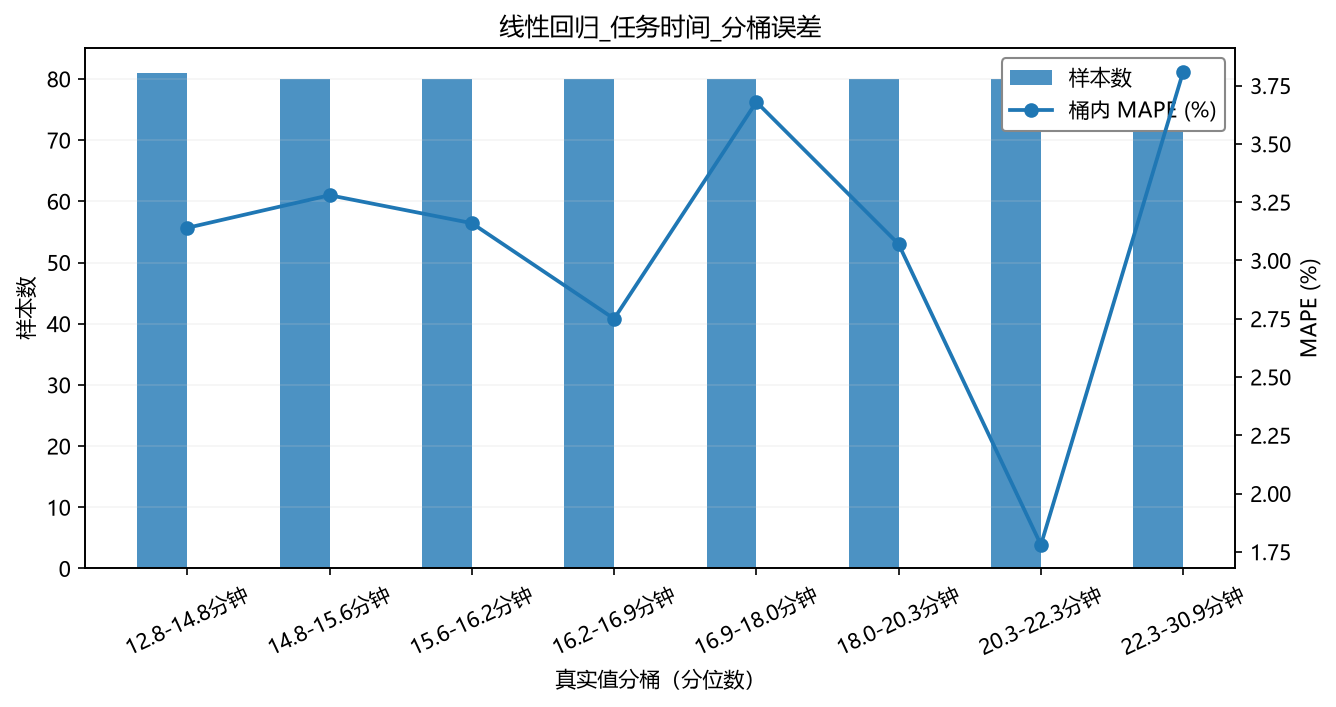

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务时间_分桶误差.png


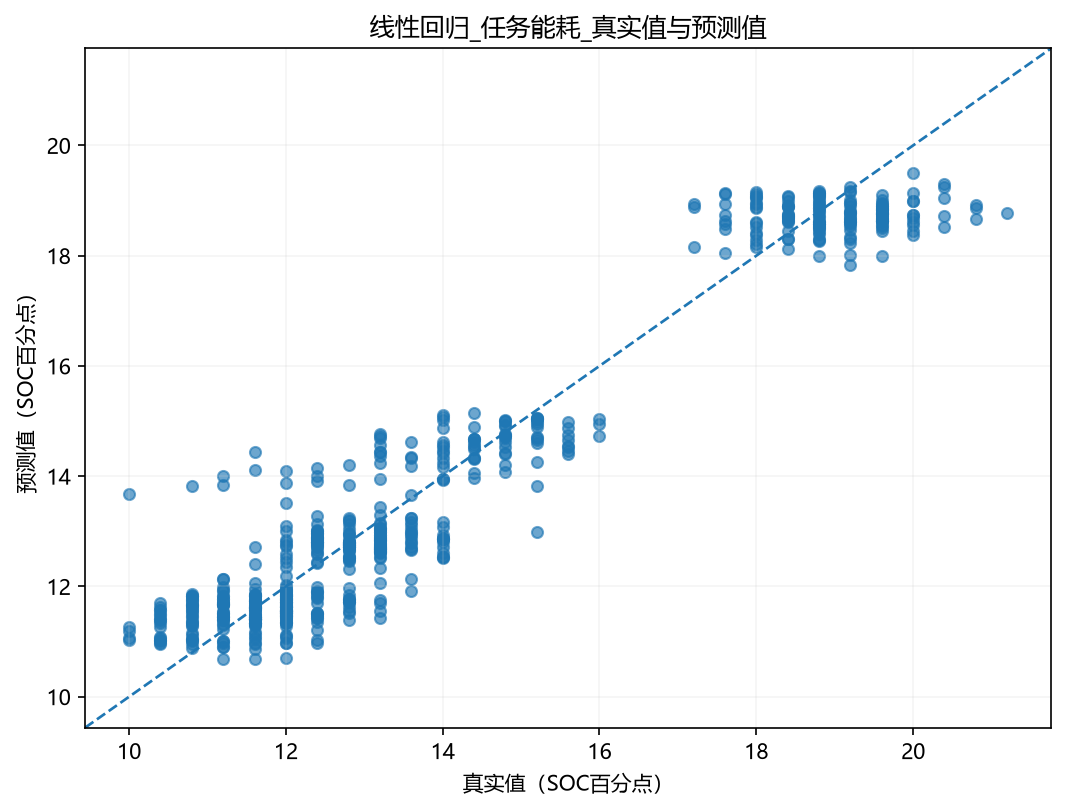

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务能耗_真实值与预测值.png


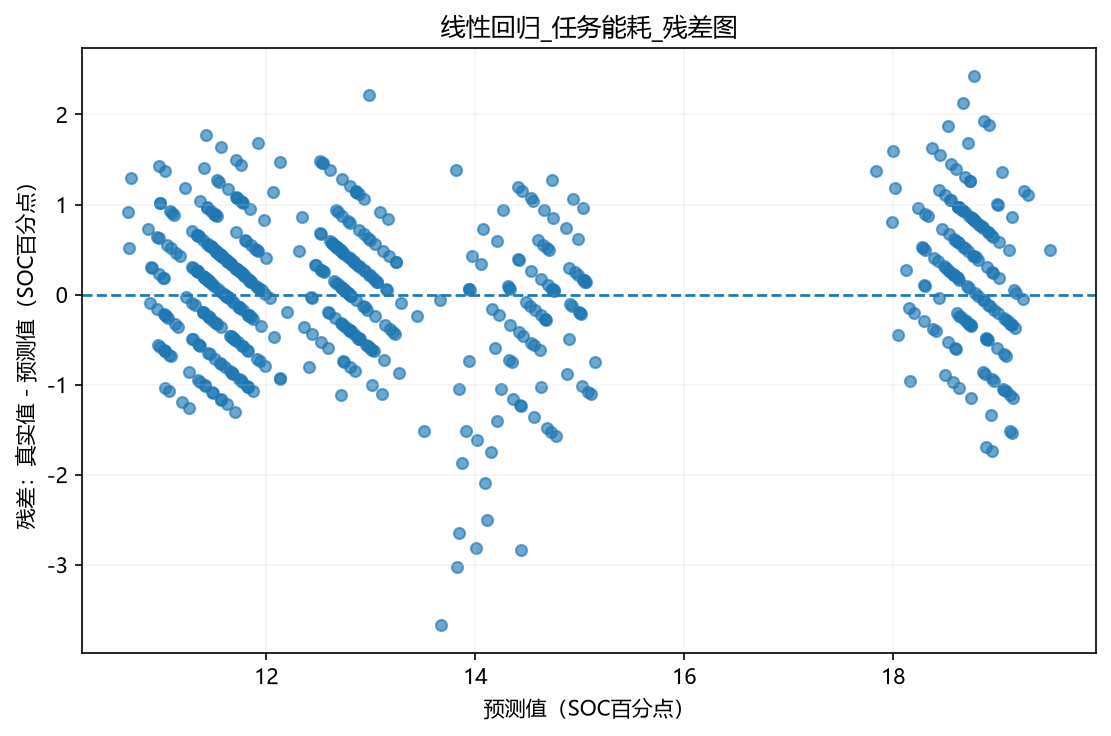

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务能耗_残差图.png


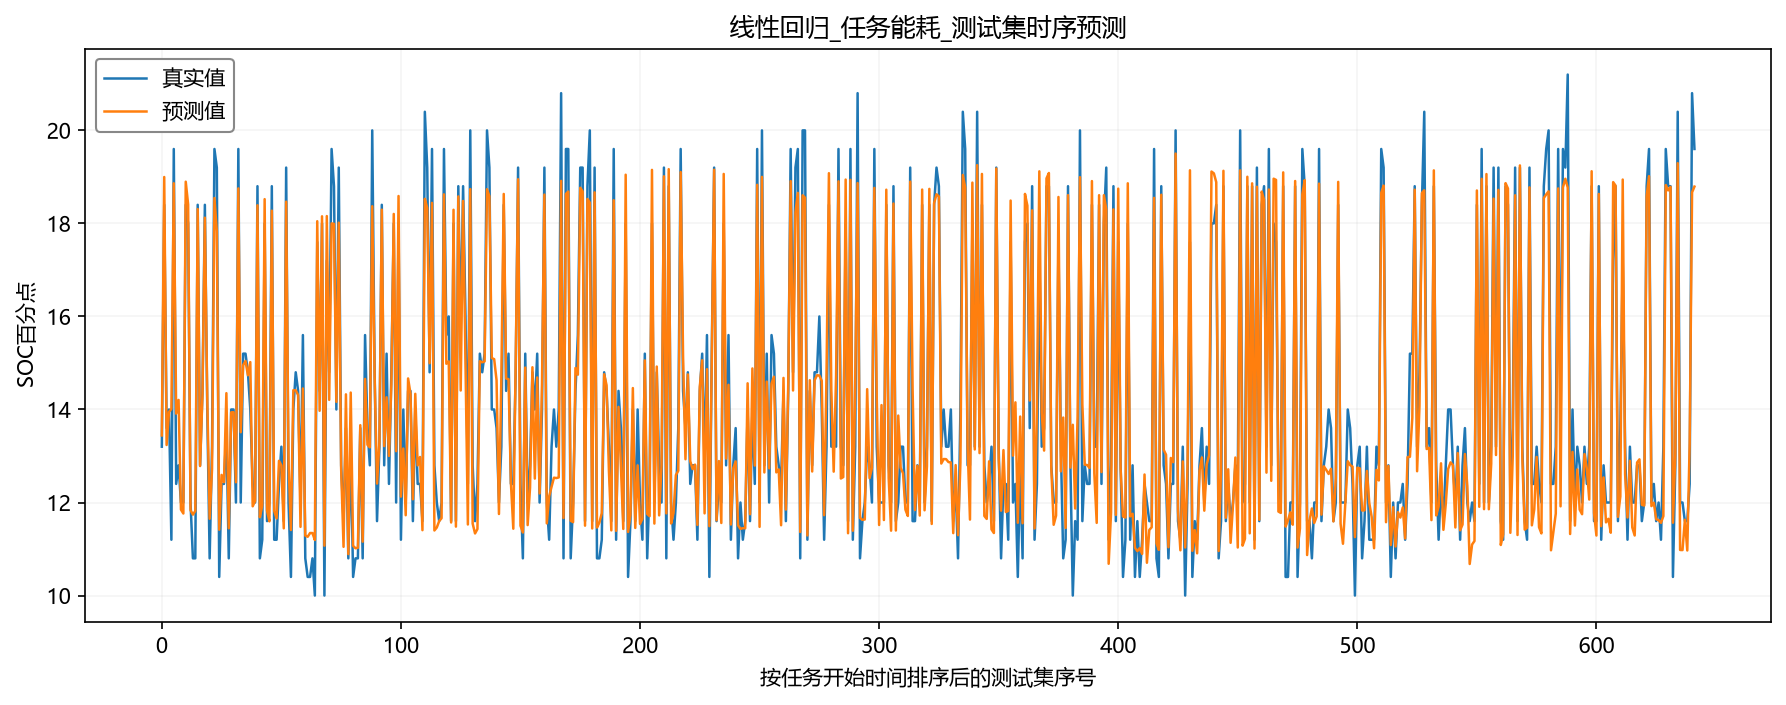

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务能耗_测试集时序预测.png


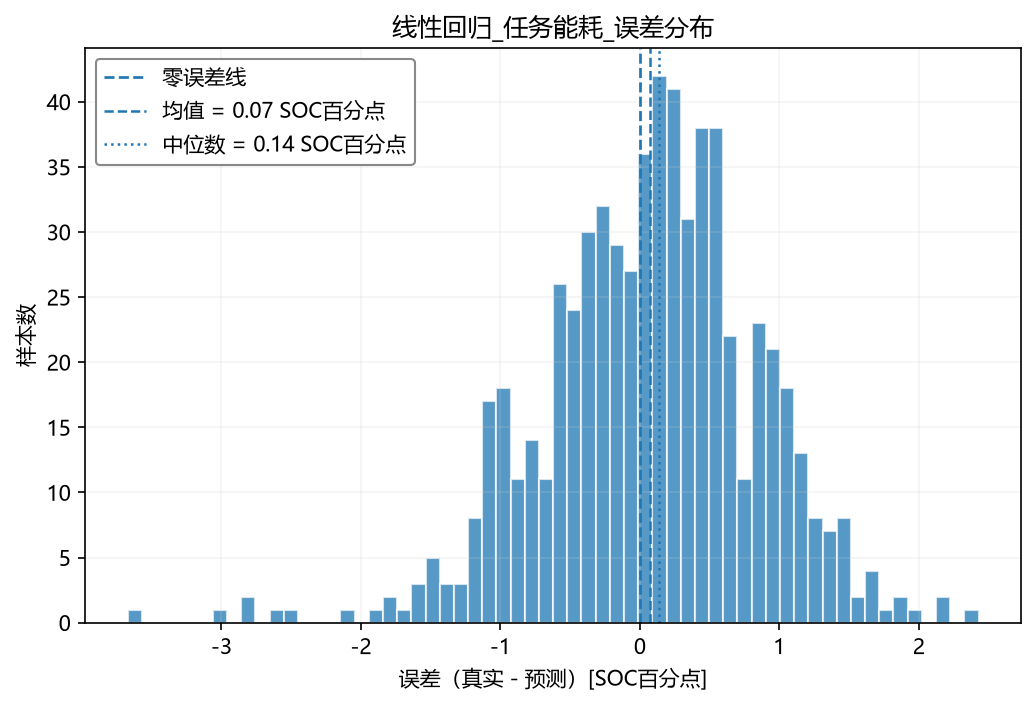

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务能耗_误差分布.png


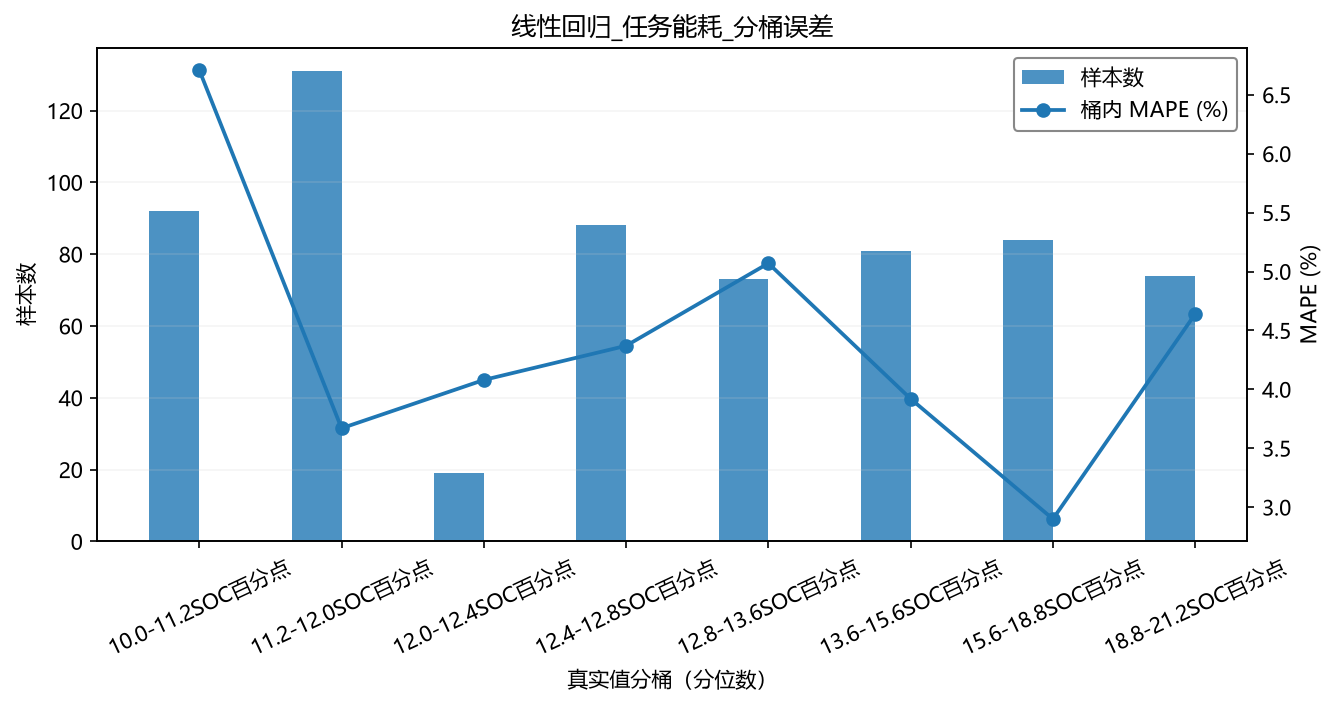

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\线性回归_任务能耗_分桶误差.png

绘图： XGBoost


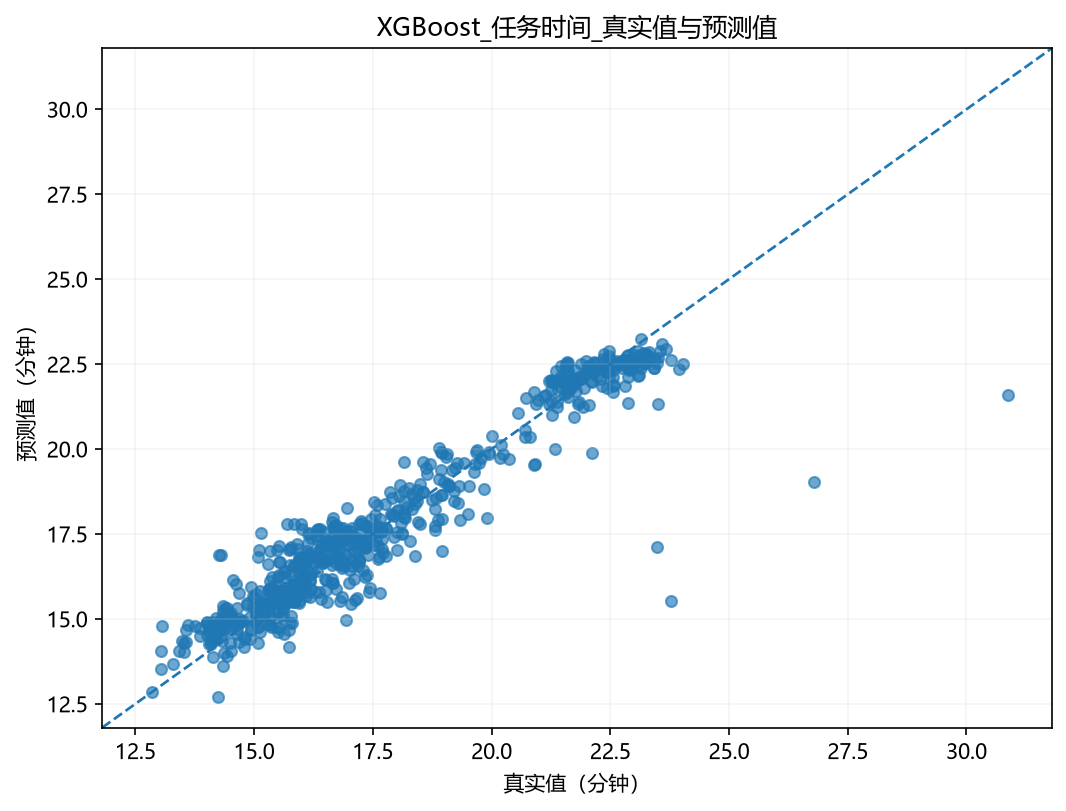

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务时间_真实值与预测值.png


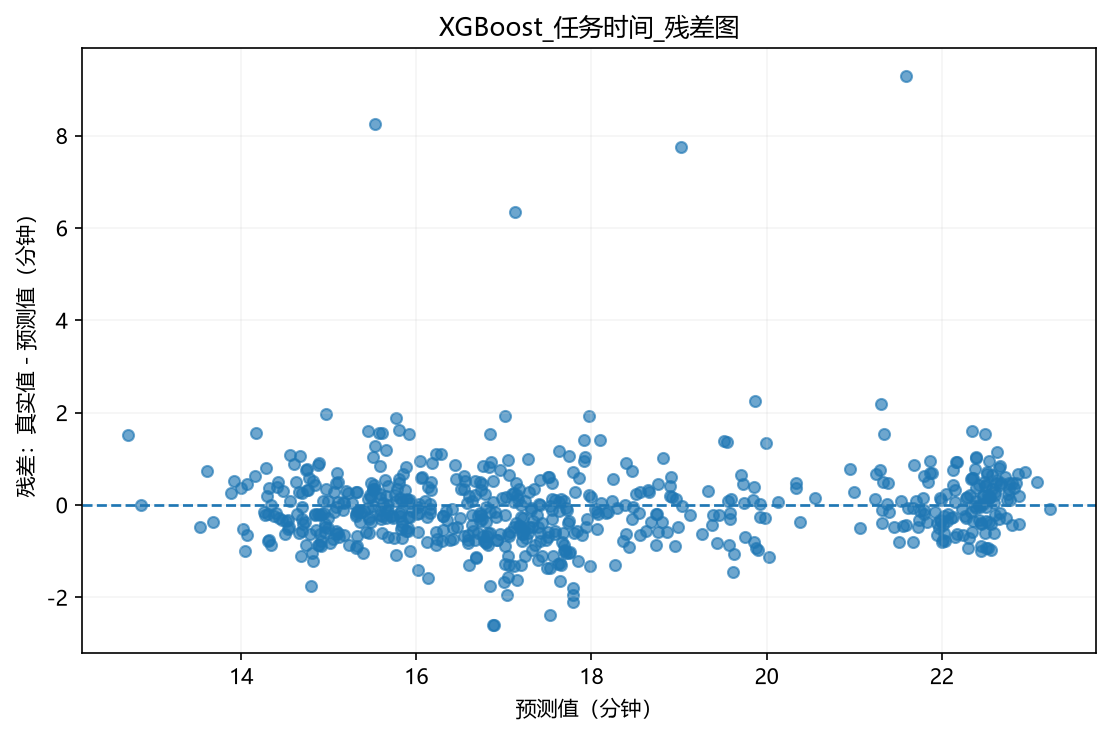

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务时间_残差图.png


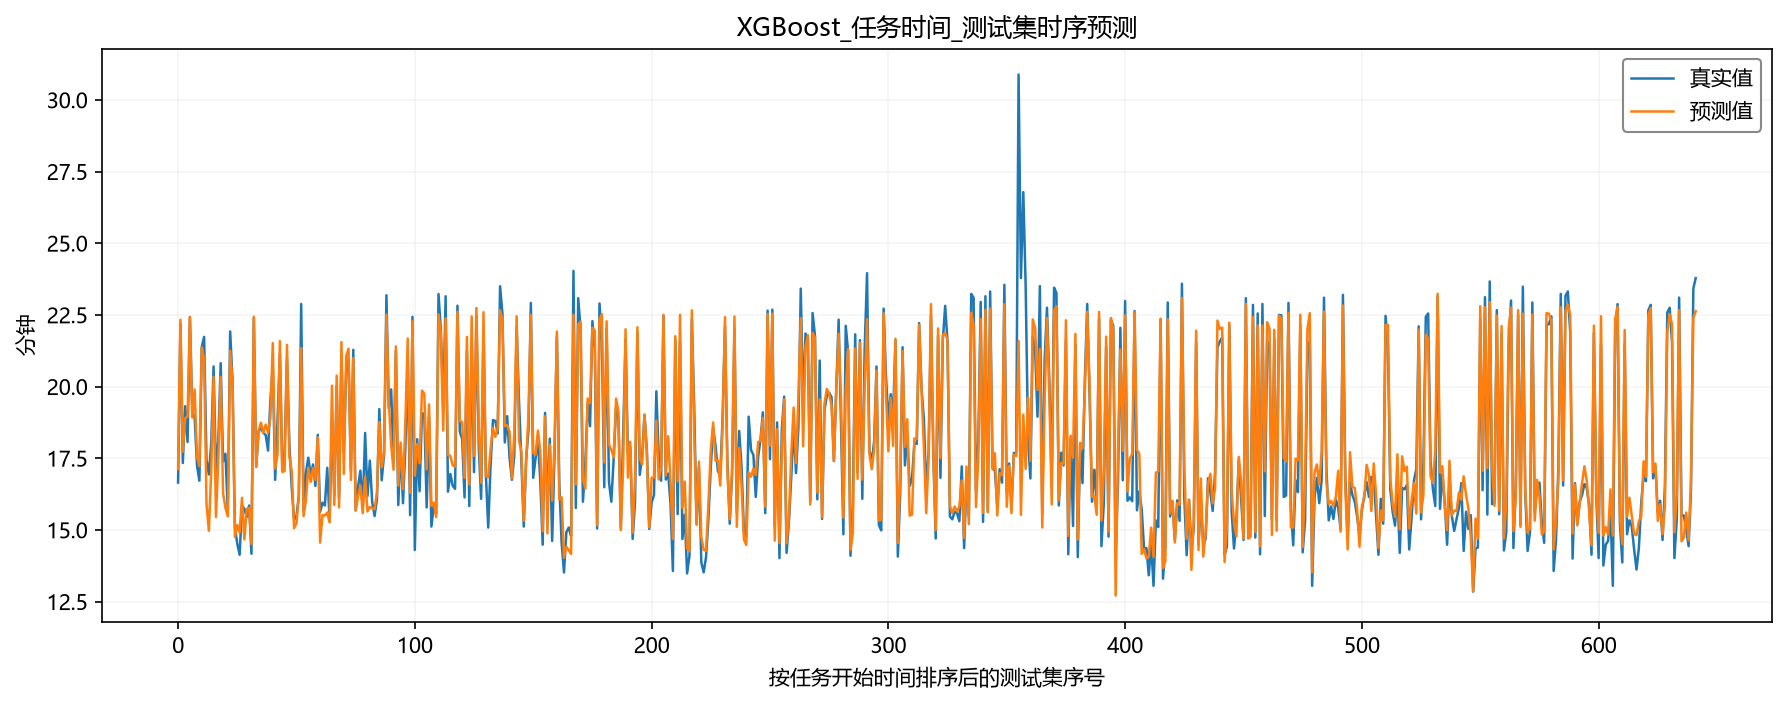

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务时间_测试集时序预测.png


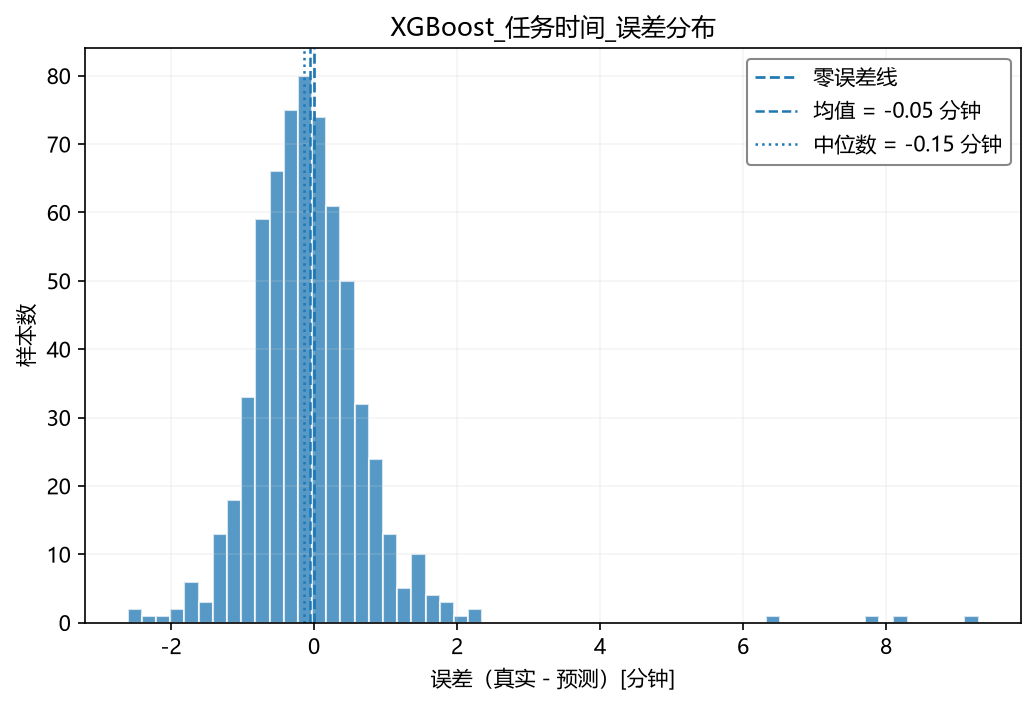

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务时间_误差分布.png


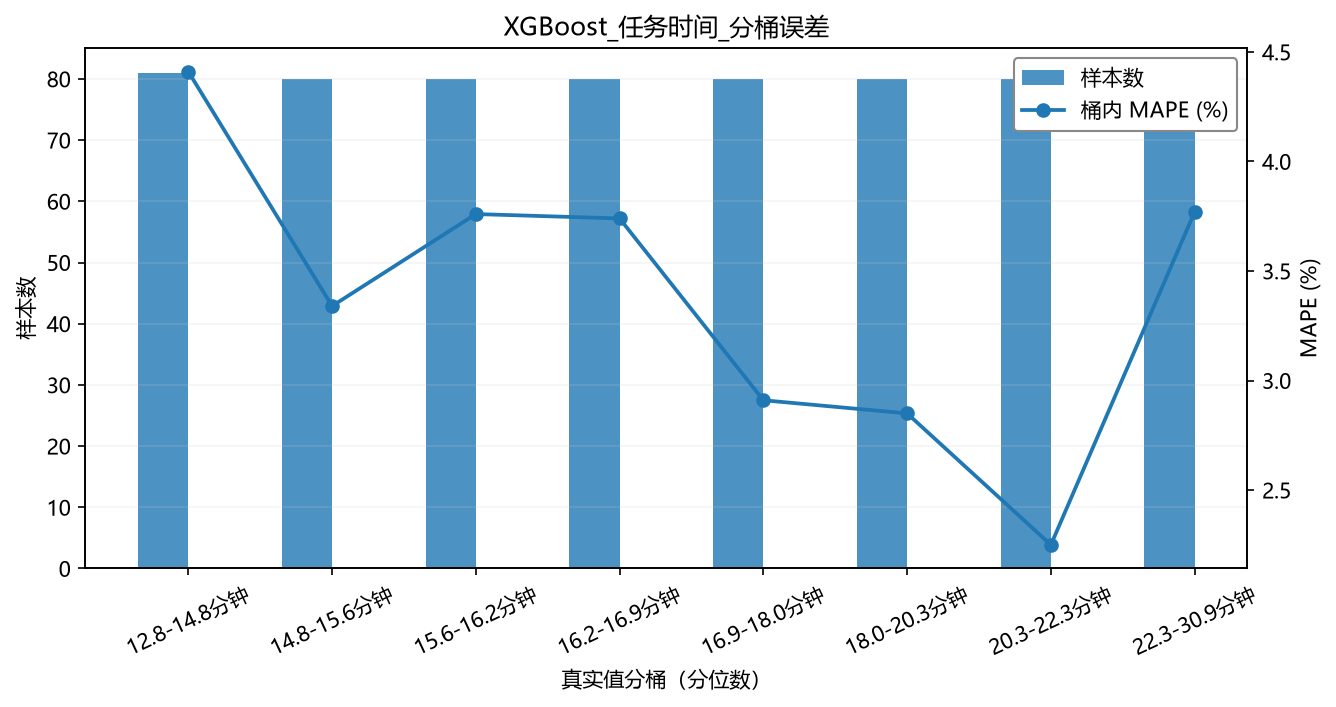

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务时间_分桶误差.png


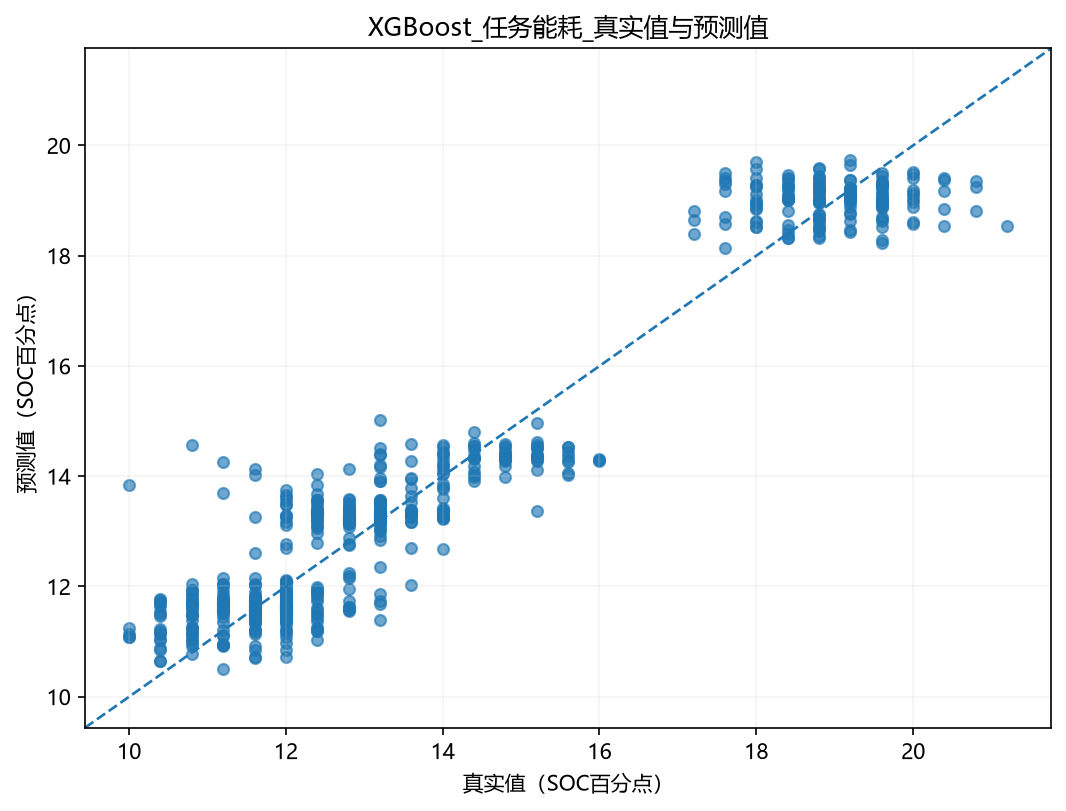

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务能耗_真实值与预测值.png


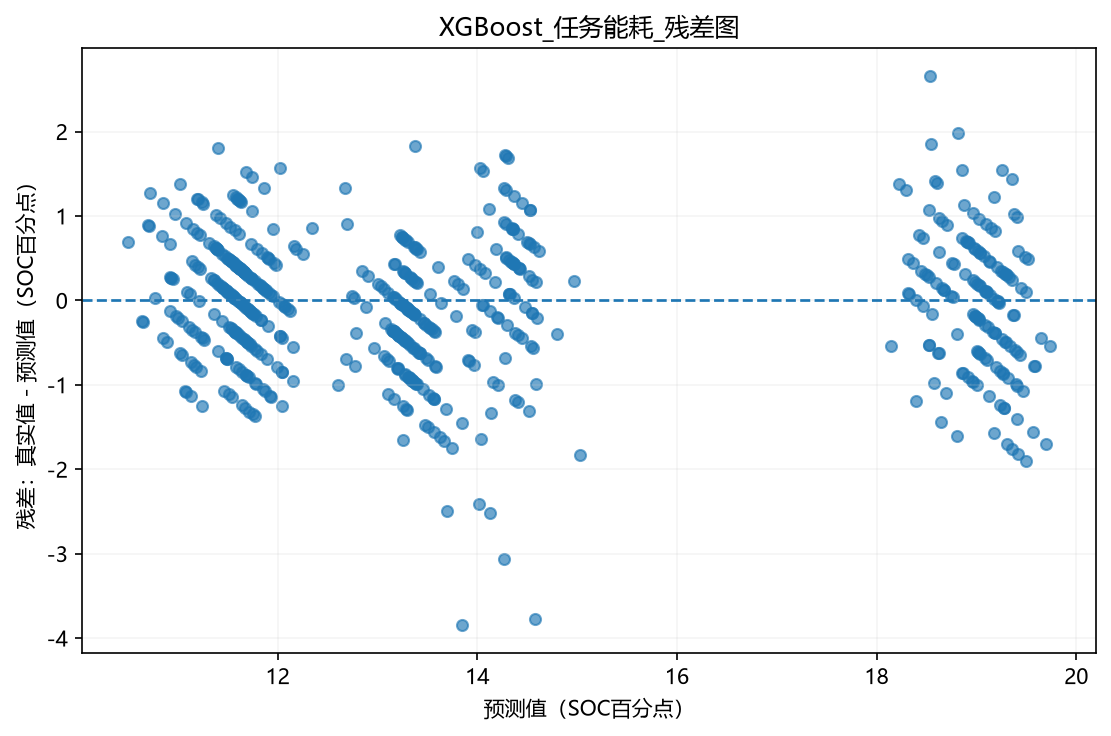

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务能耗_残差图.png


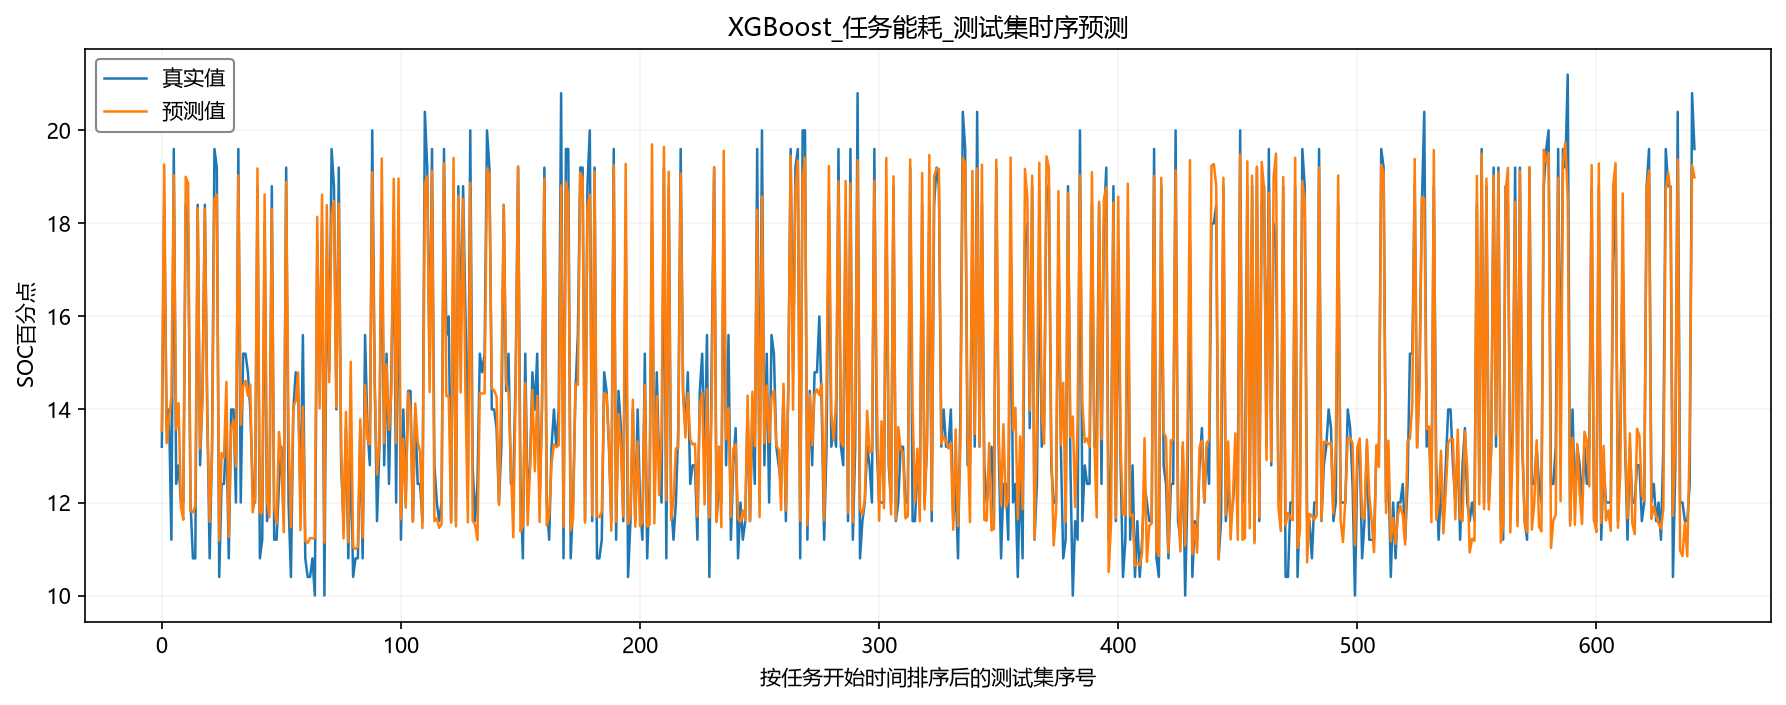

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务能耗_测试集时序预测.png


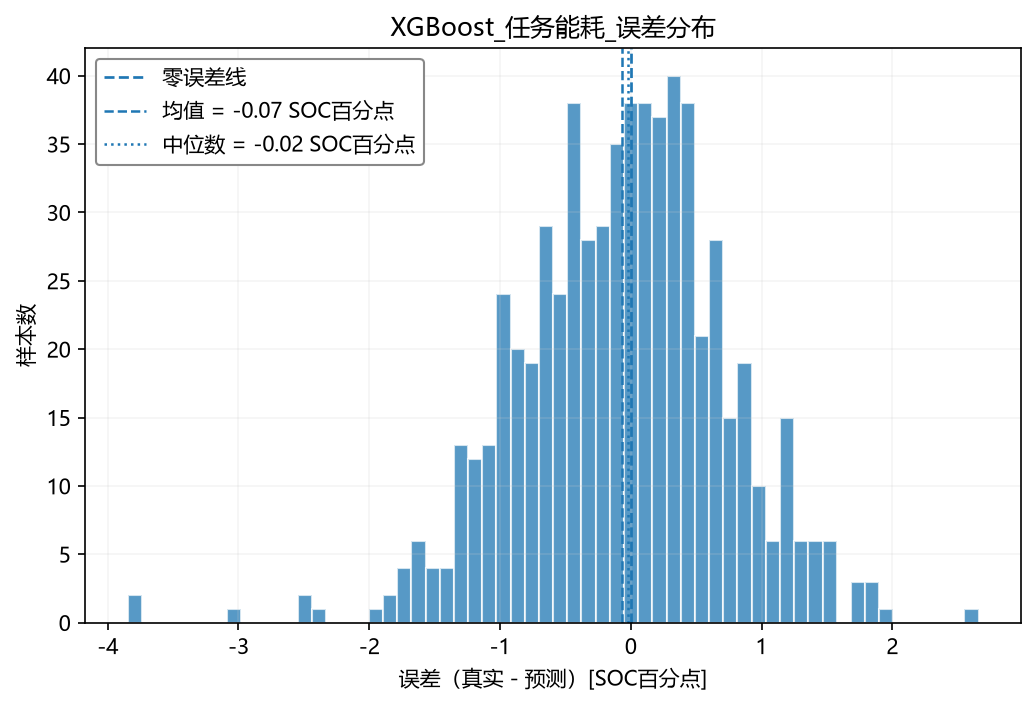

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务能耗_误差分布.png


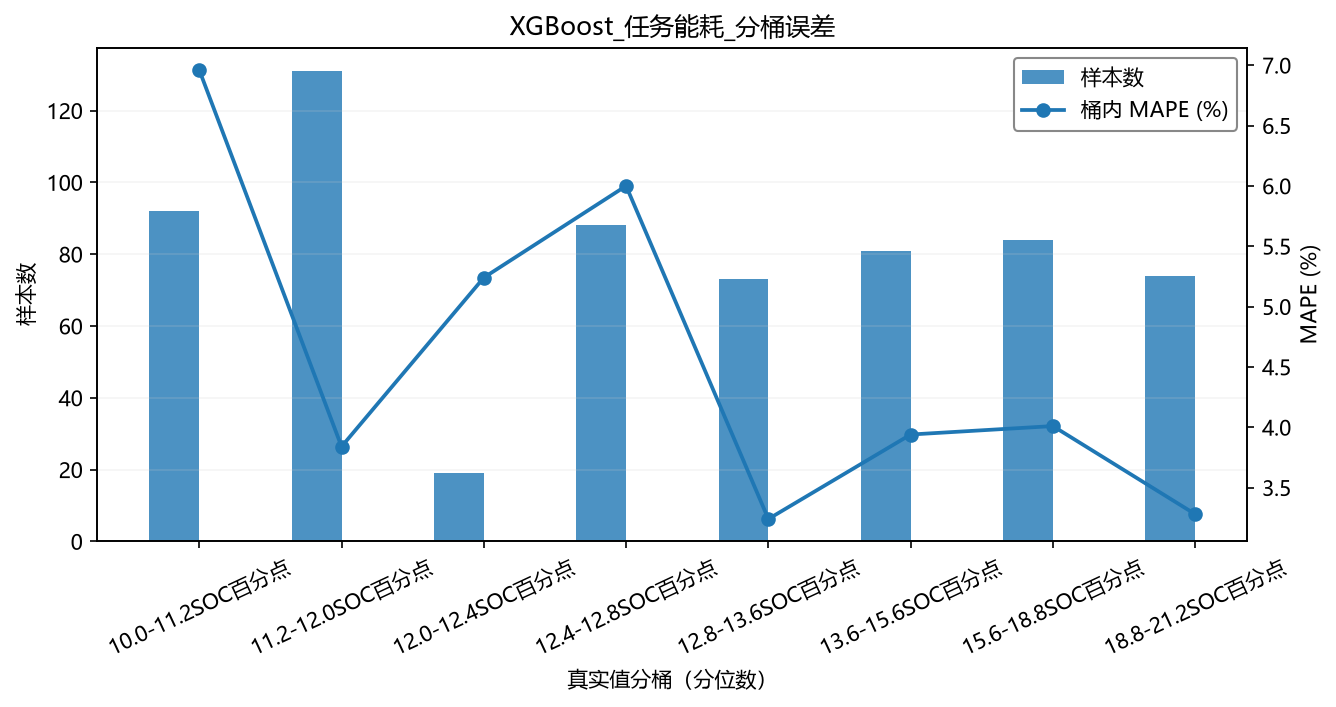

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\XGBoost_任务能耗_分桶误差.png

绘图： LightGBM


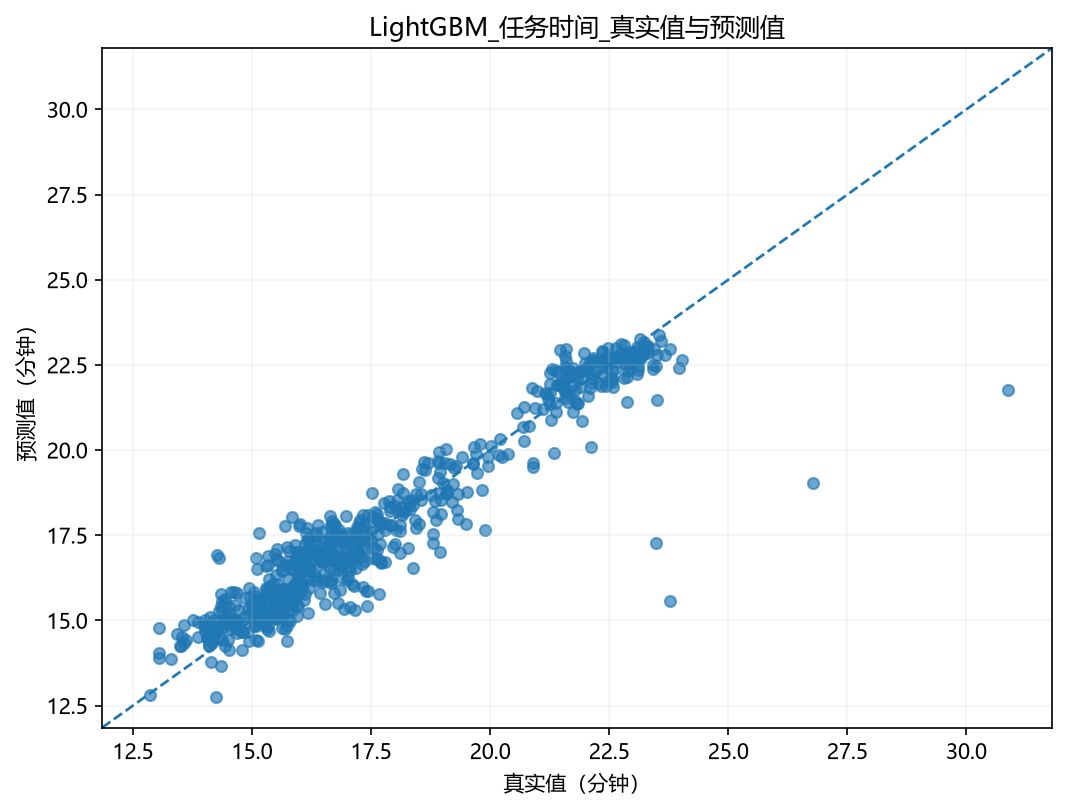

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务时间_真实值与预测值.png


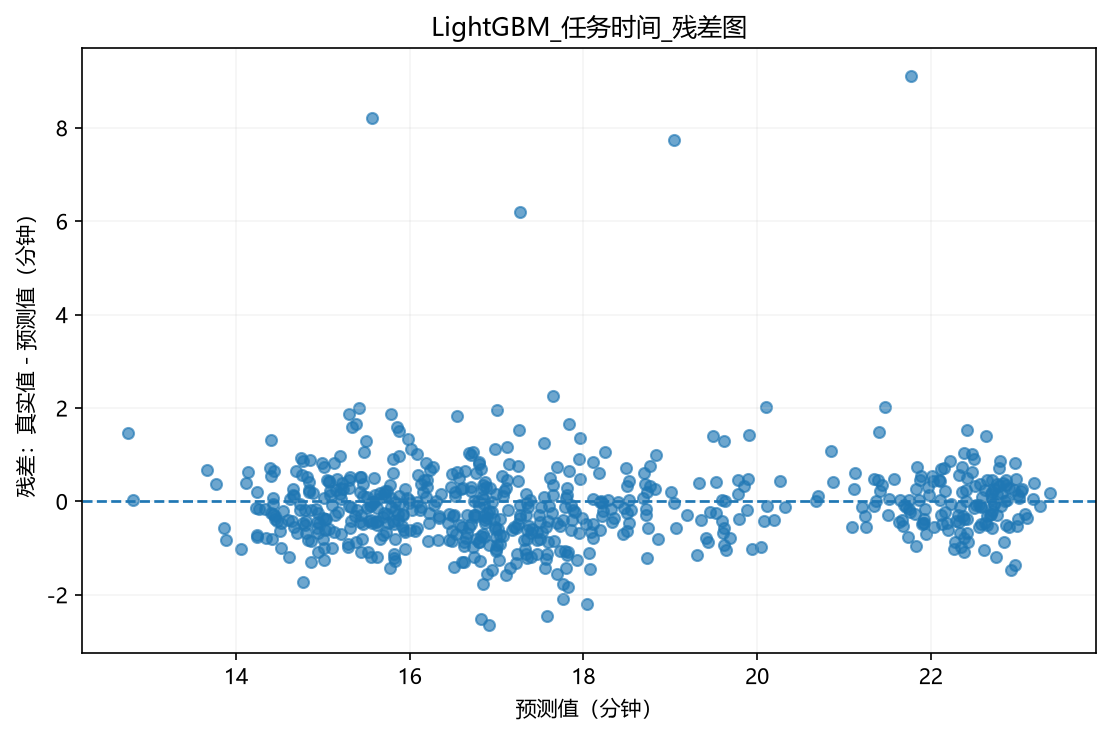

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务时间_残差图.png


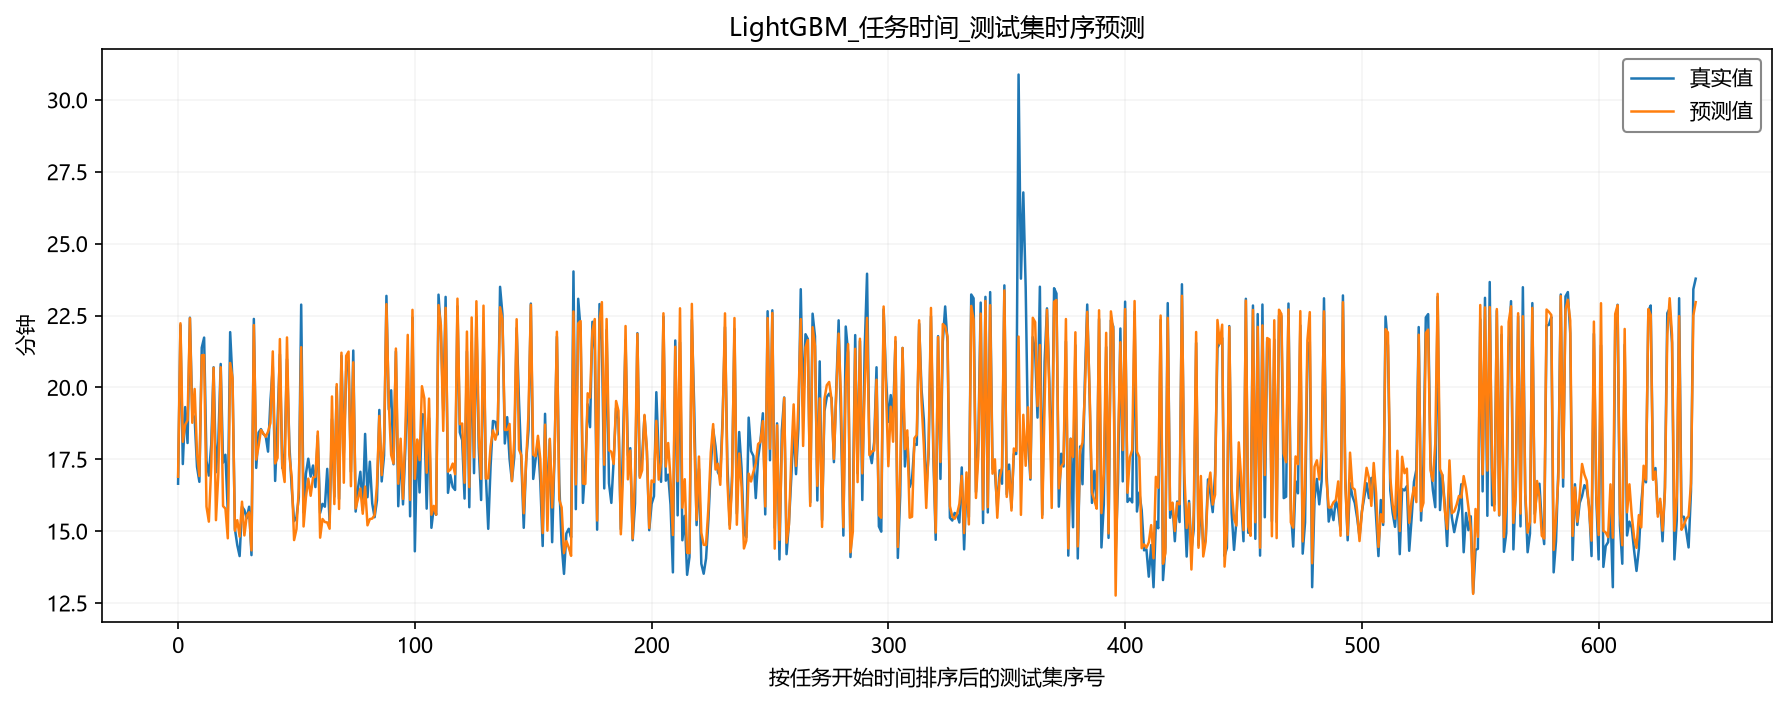

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务时间_测试集时序预测.png


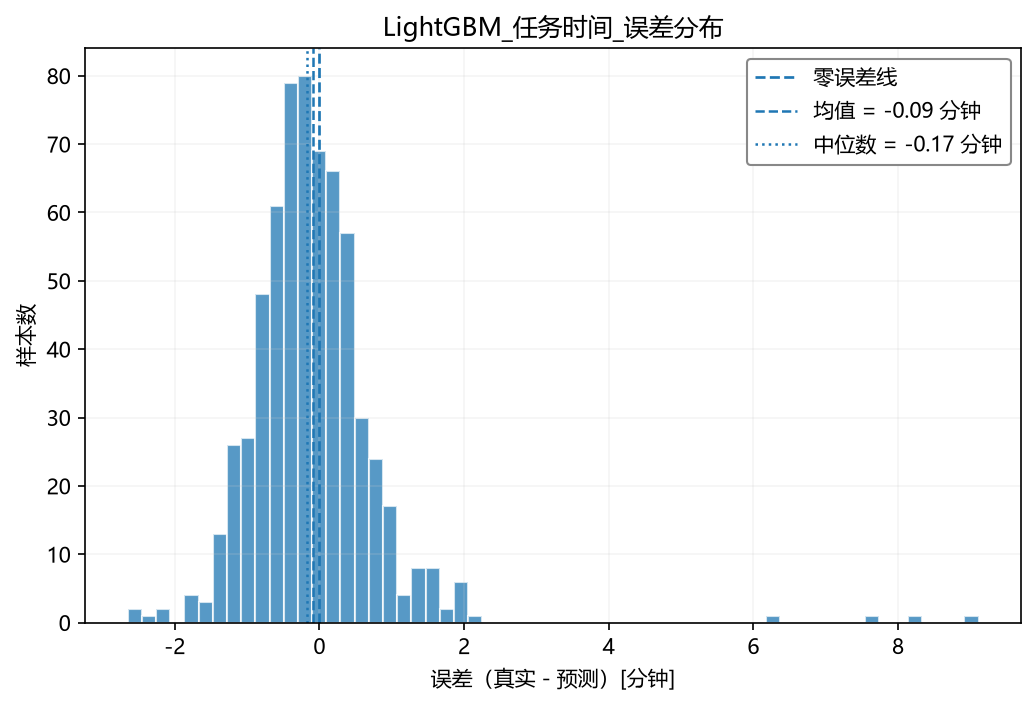

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务时间_误差分布.png


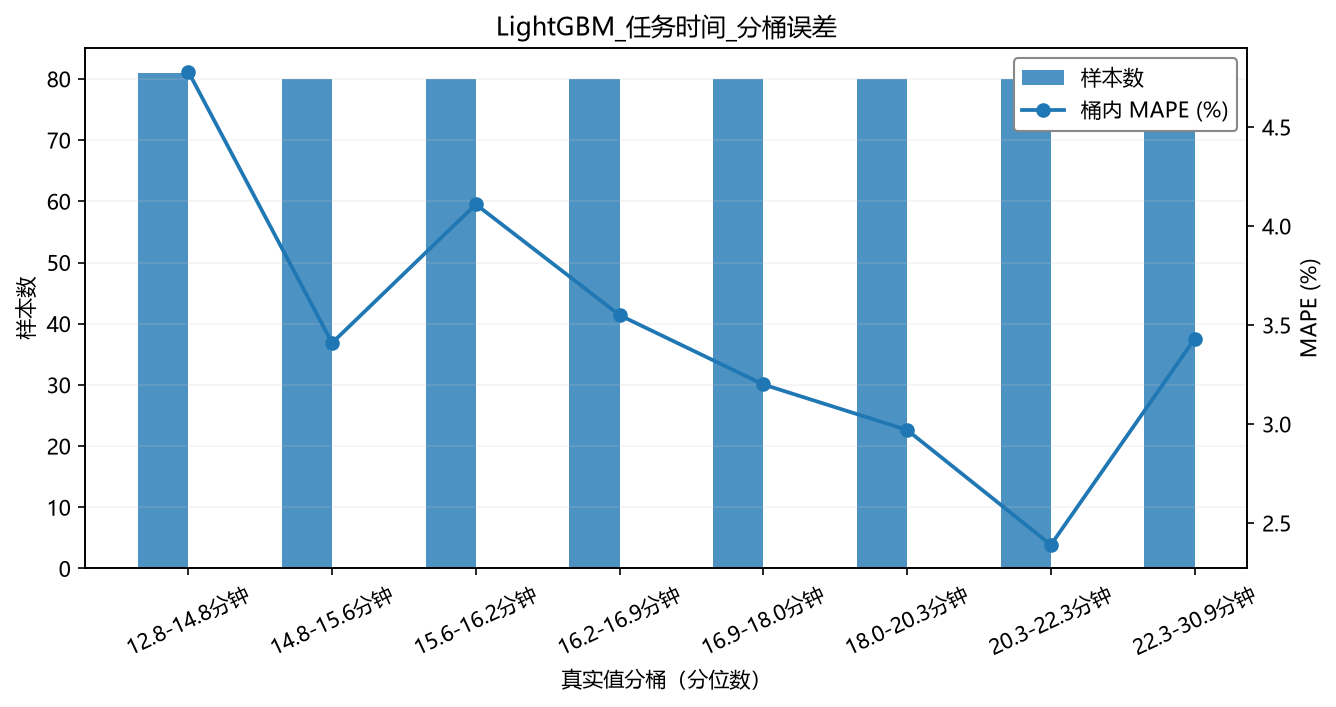

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务时间_分桶误差.png


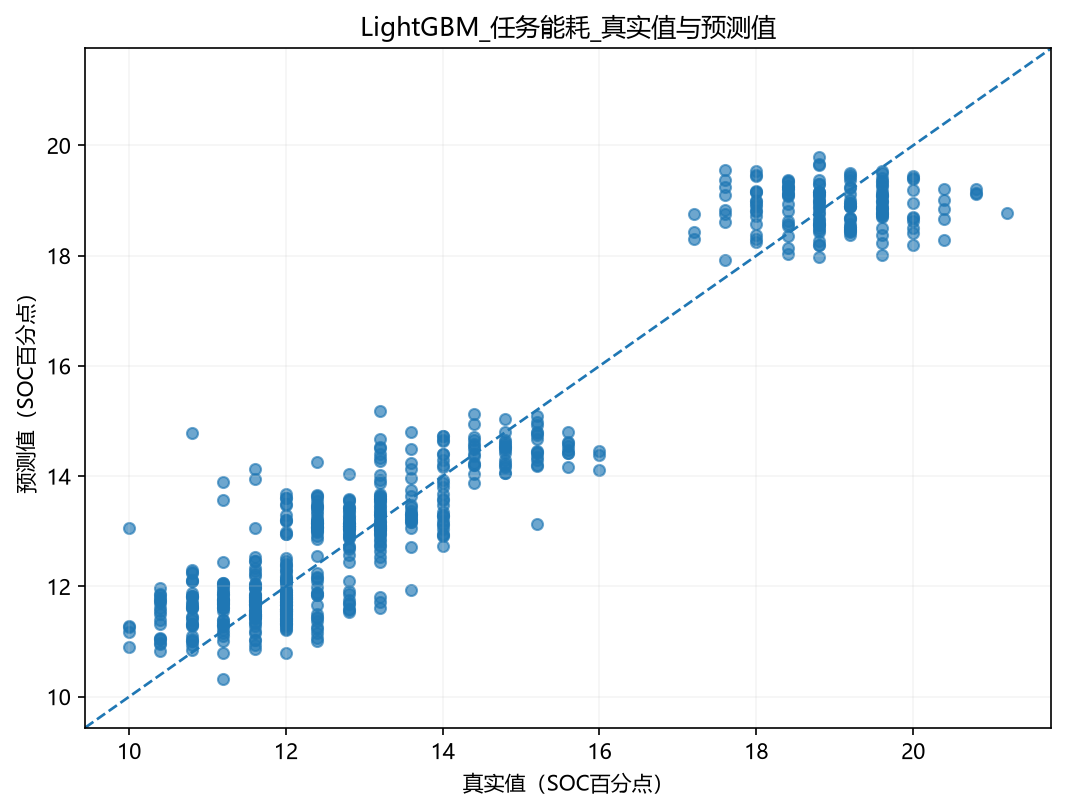

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务能耗_真实值与预测值.png


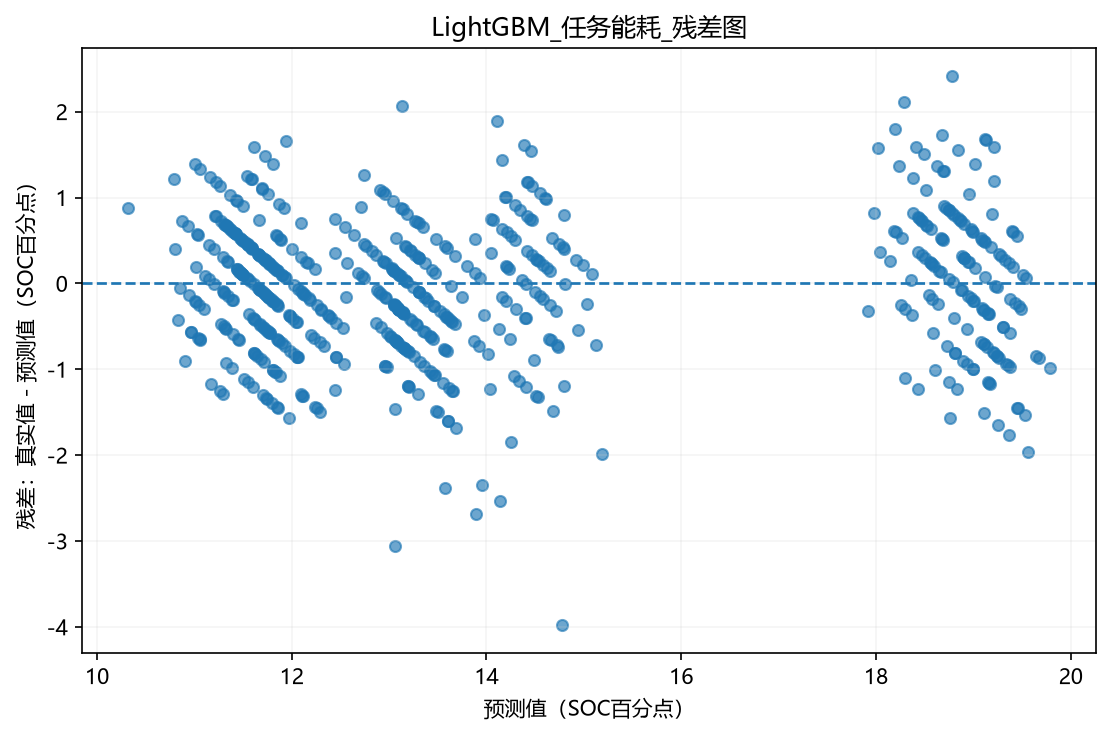

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务能耗_残差图.png


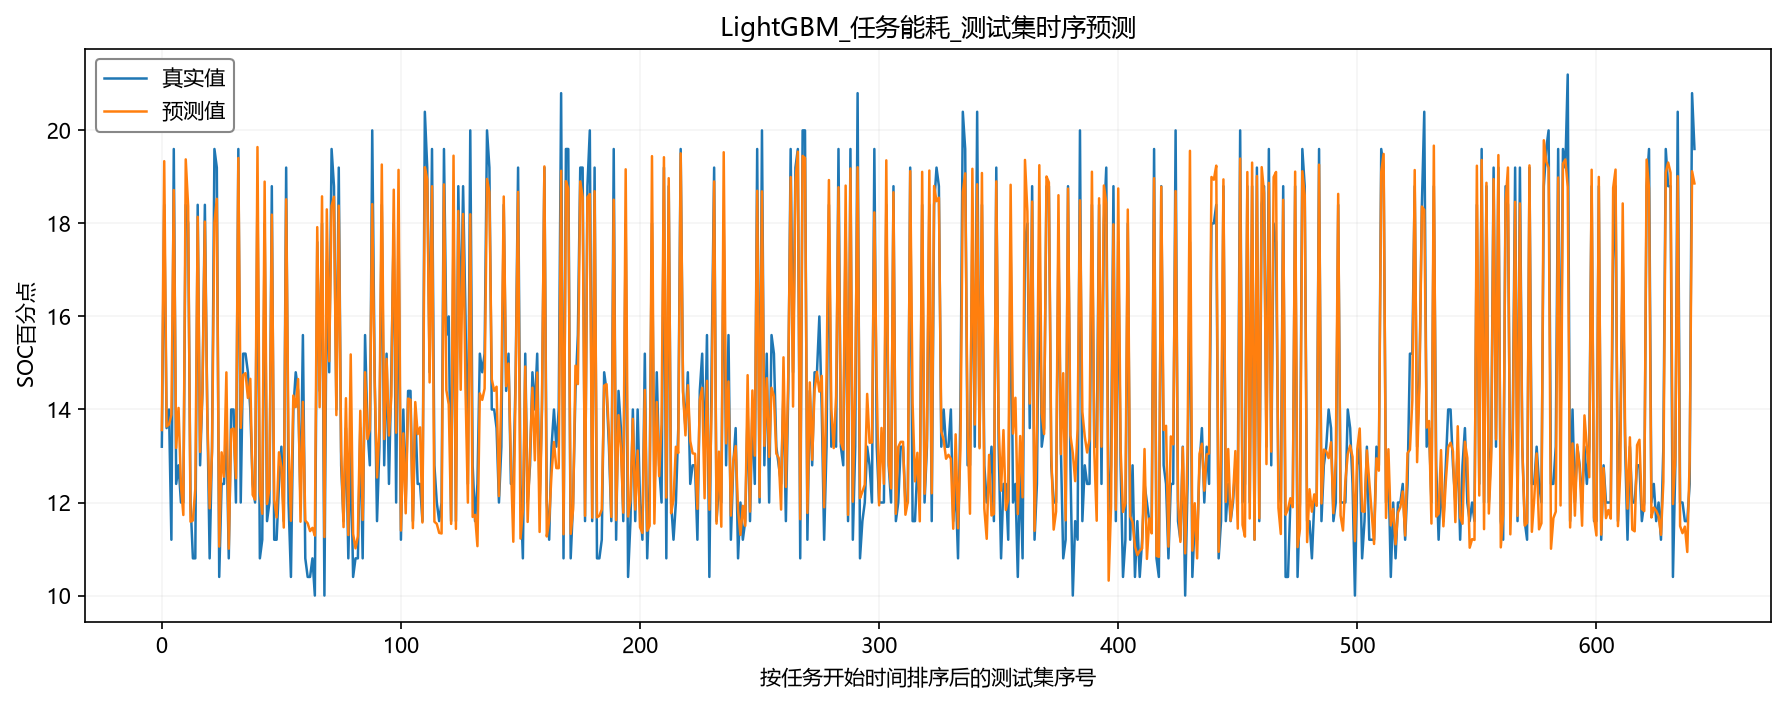

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务能耗_测试集时序预测.png


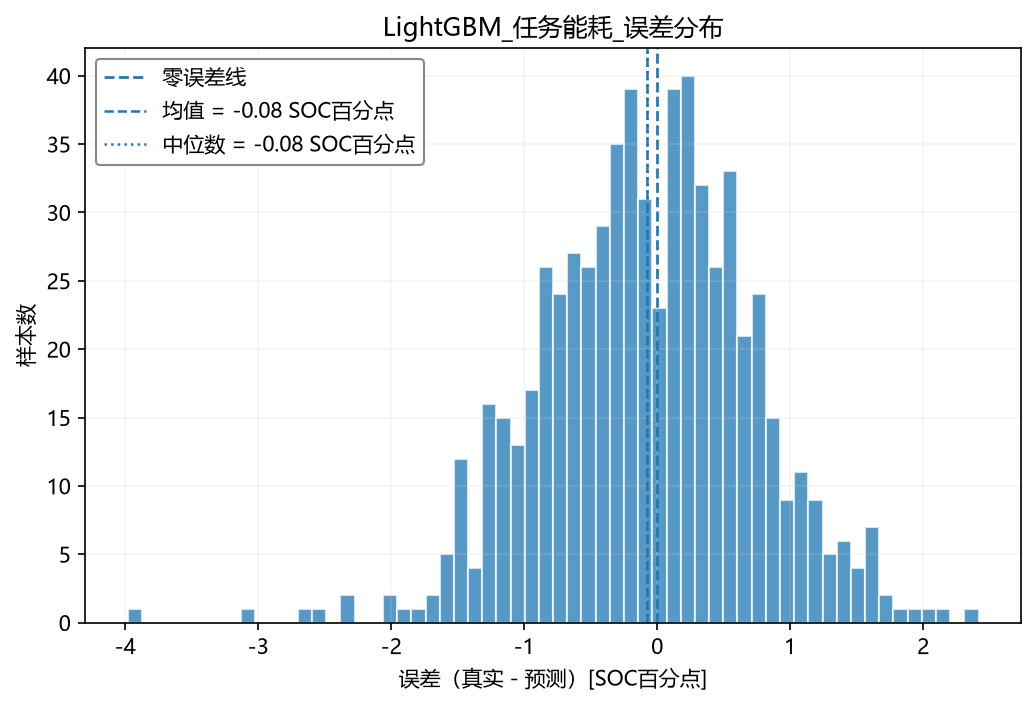

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务能耗_误差分布.png


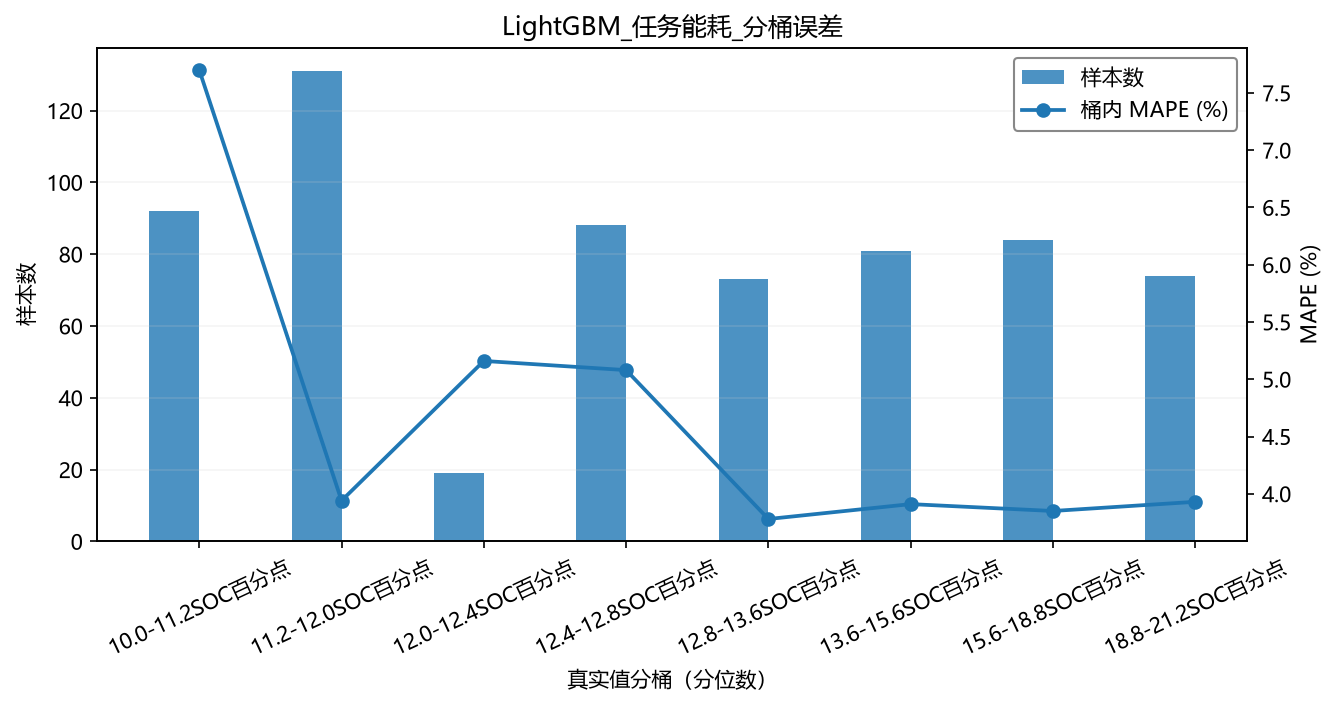

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\LightGBM_任务能耗_分桶误差.png

绘图： 随机森林


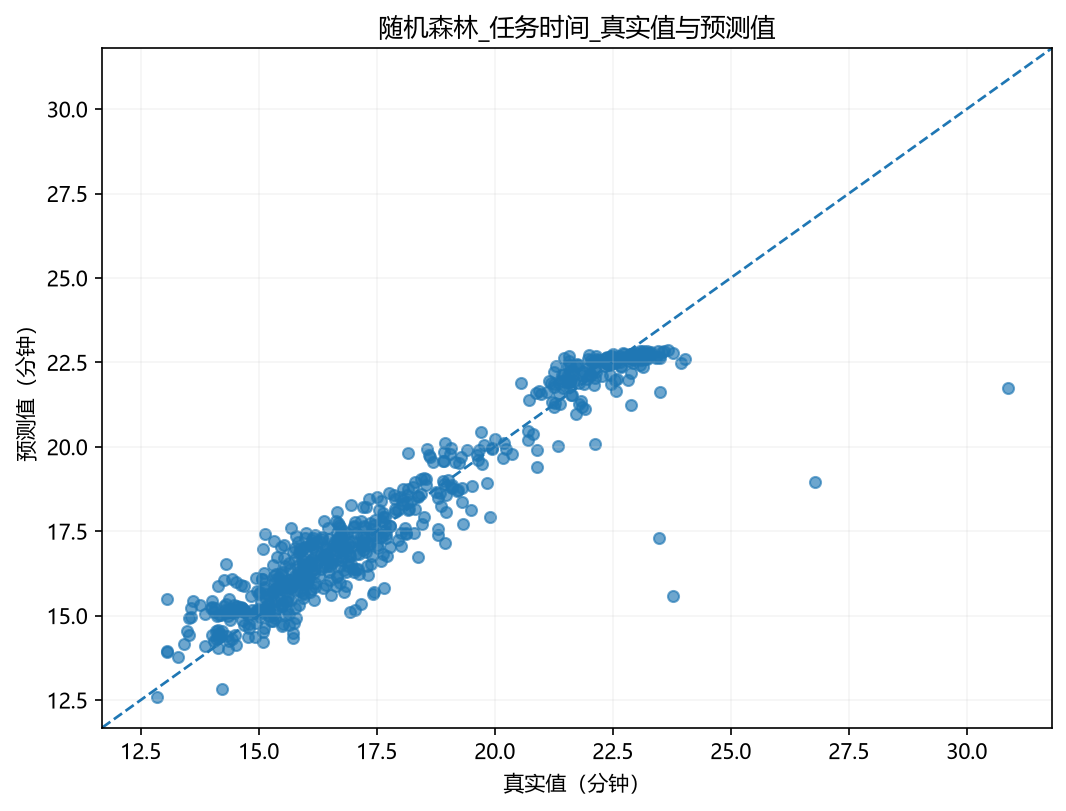

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务时间_真实值与预测值.png


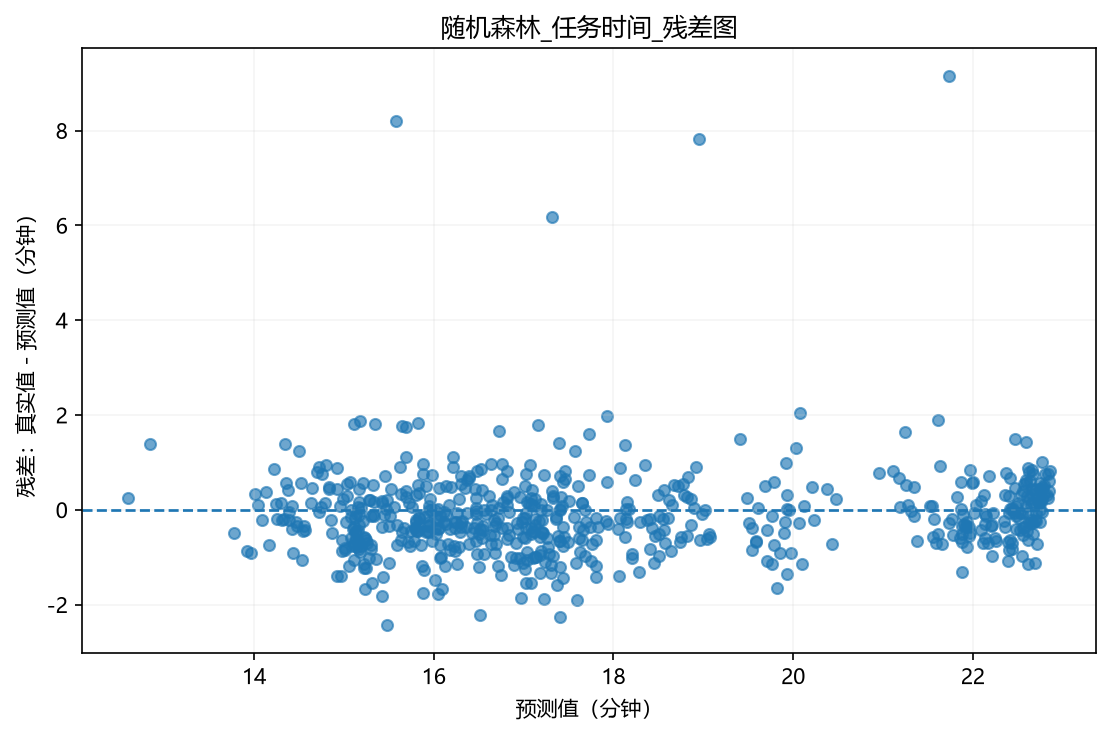

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务时间_残差图.png


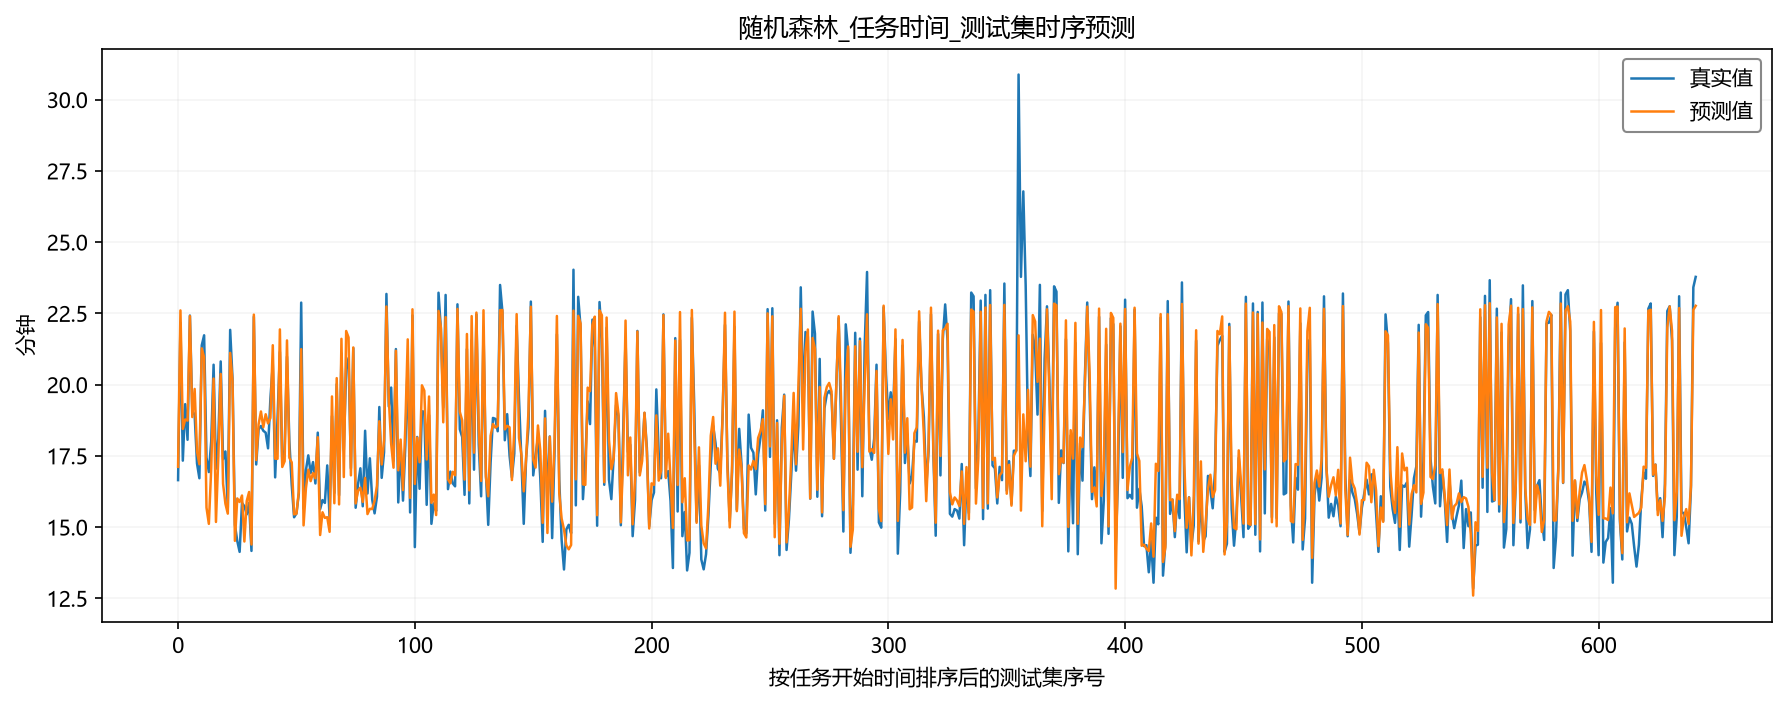

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务时间_测试集时序预测.png


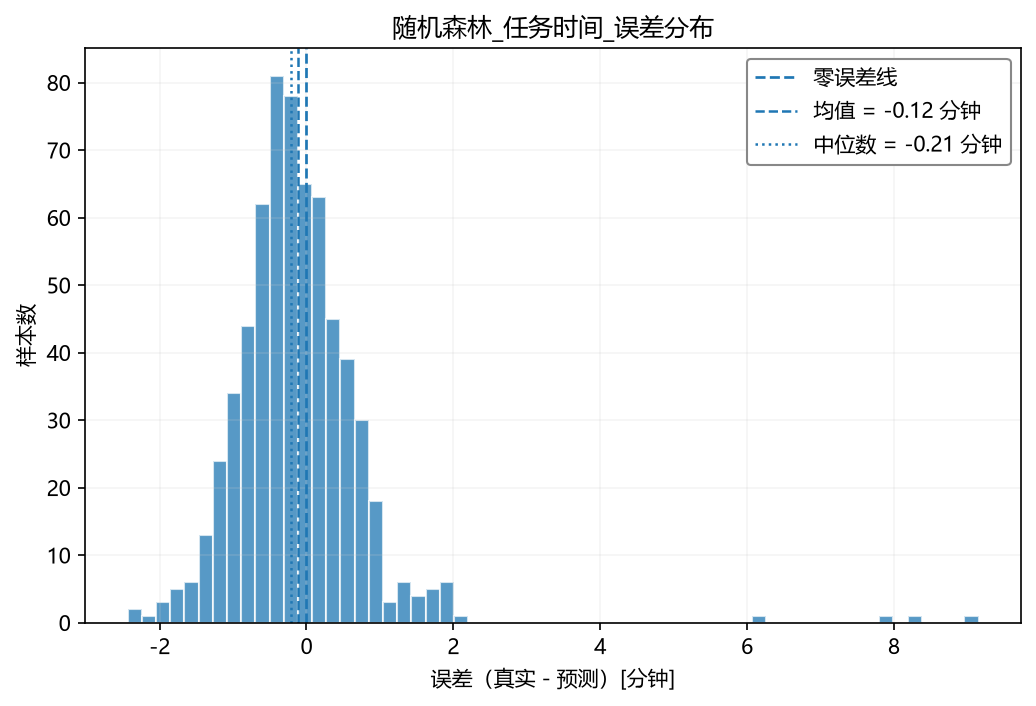

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务时间_误差分布.png


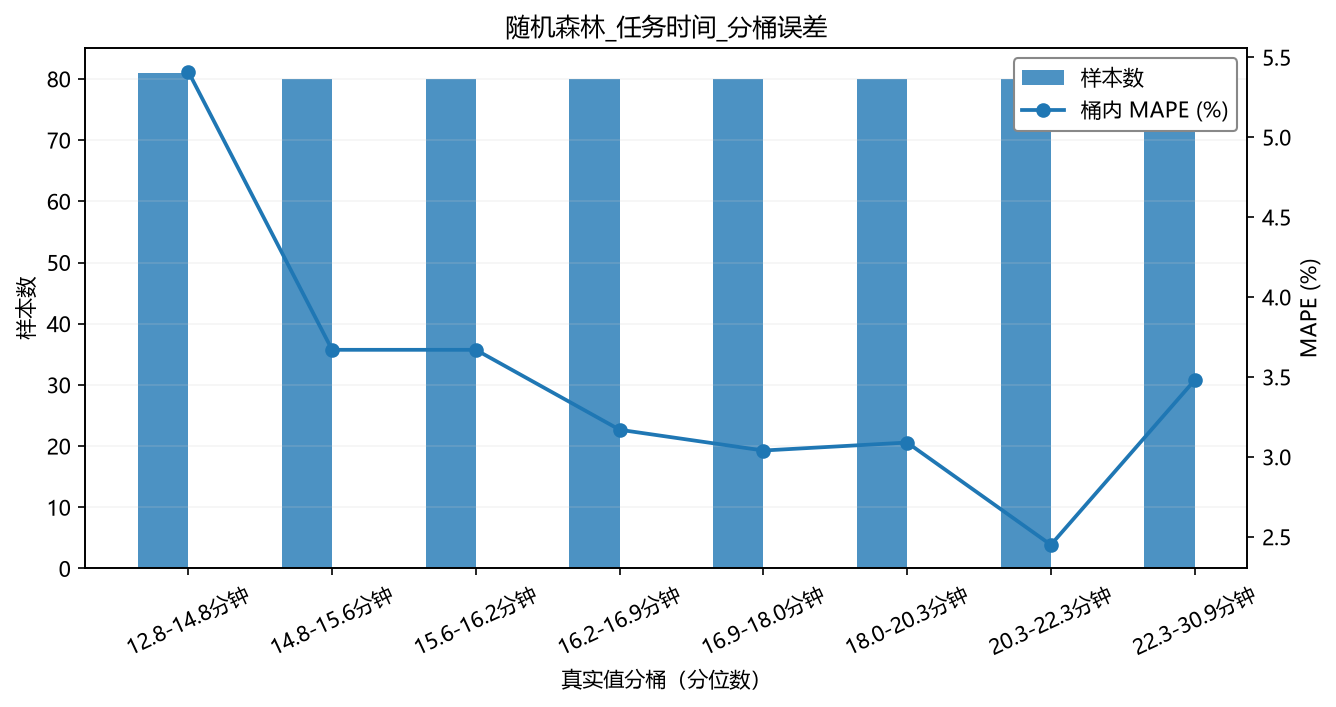

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务时间_分桶误差.png


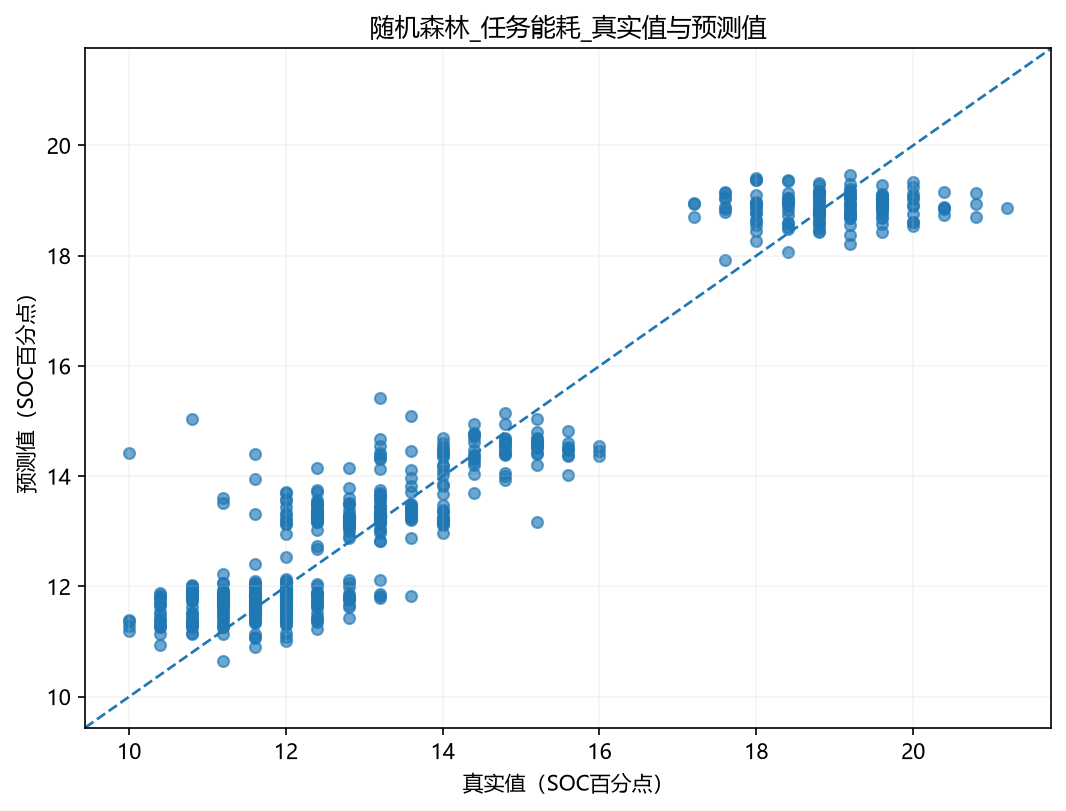

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务能耗_真实值与预测值.png


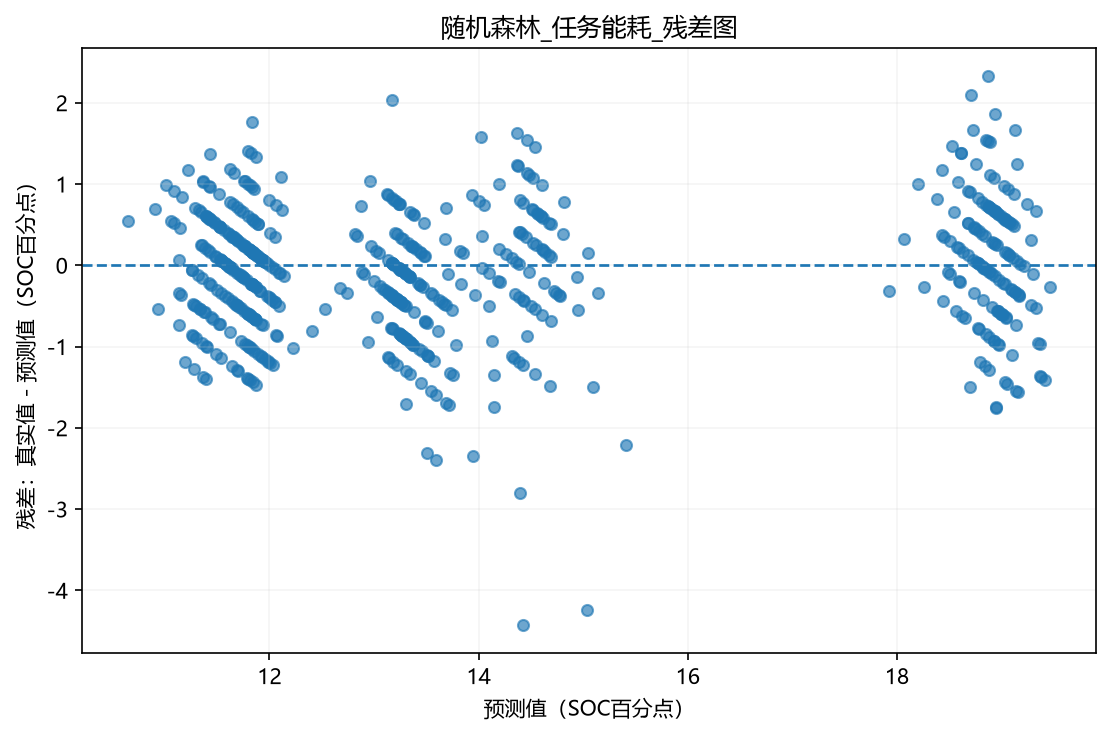

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务能耗_残差图.png


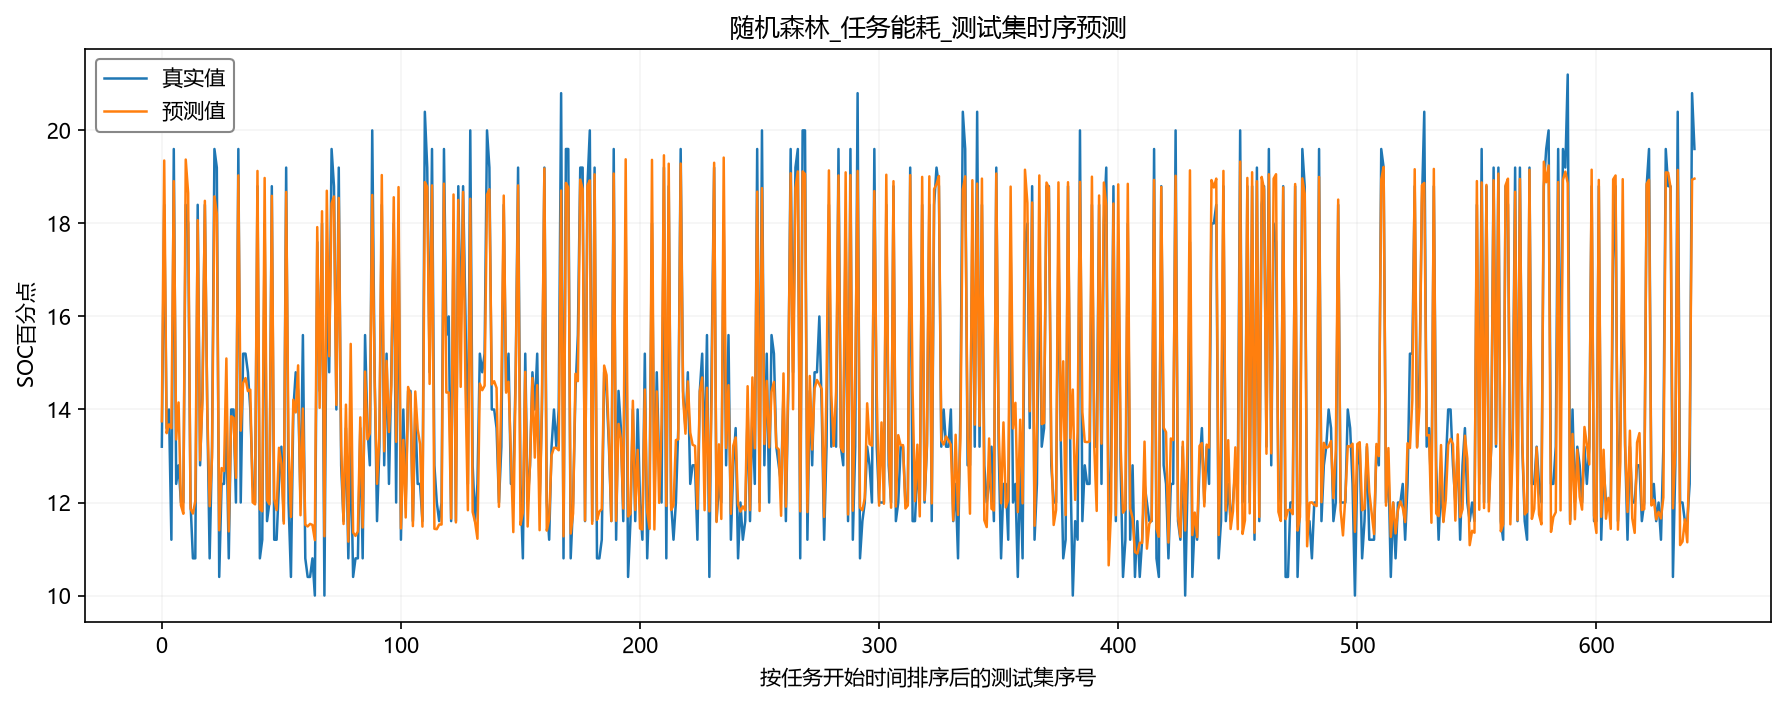

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务能耗_测试集时序预测.png


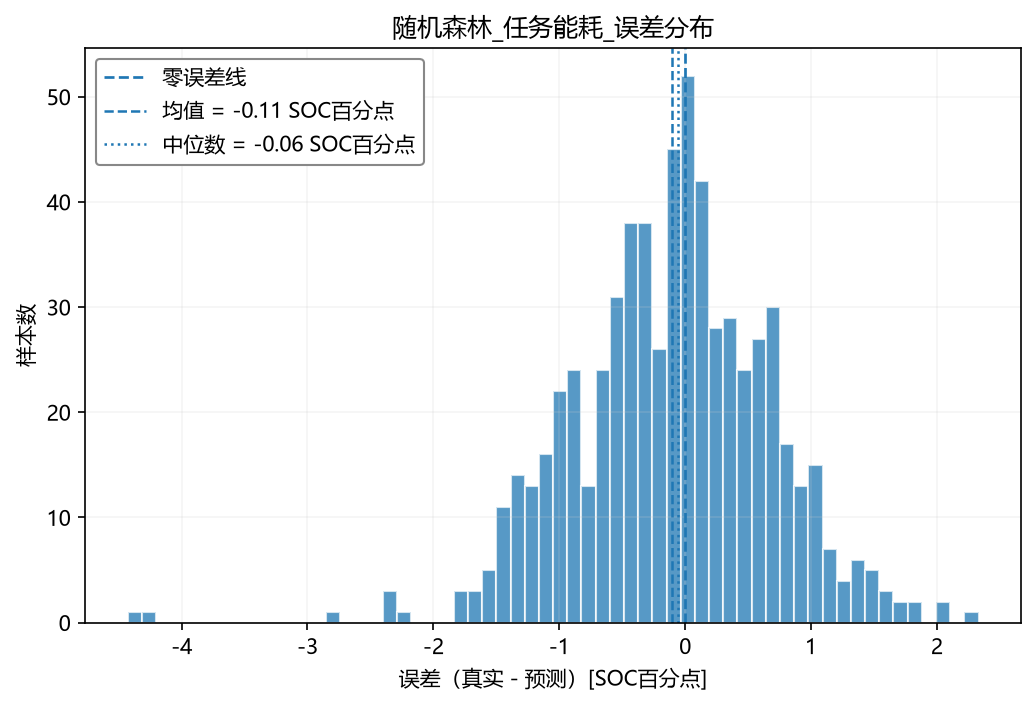

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务能耗_误差分布.png


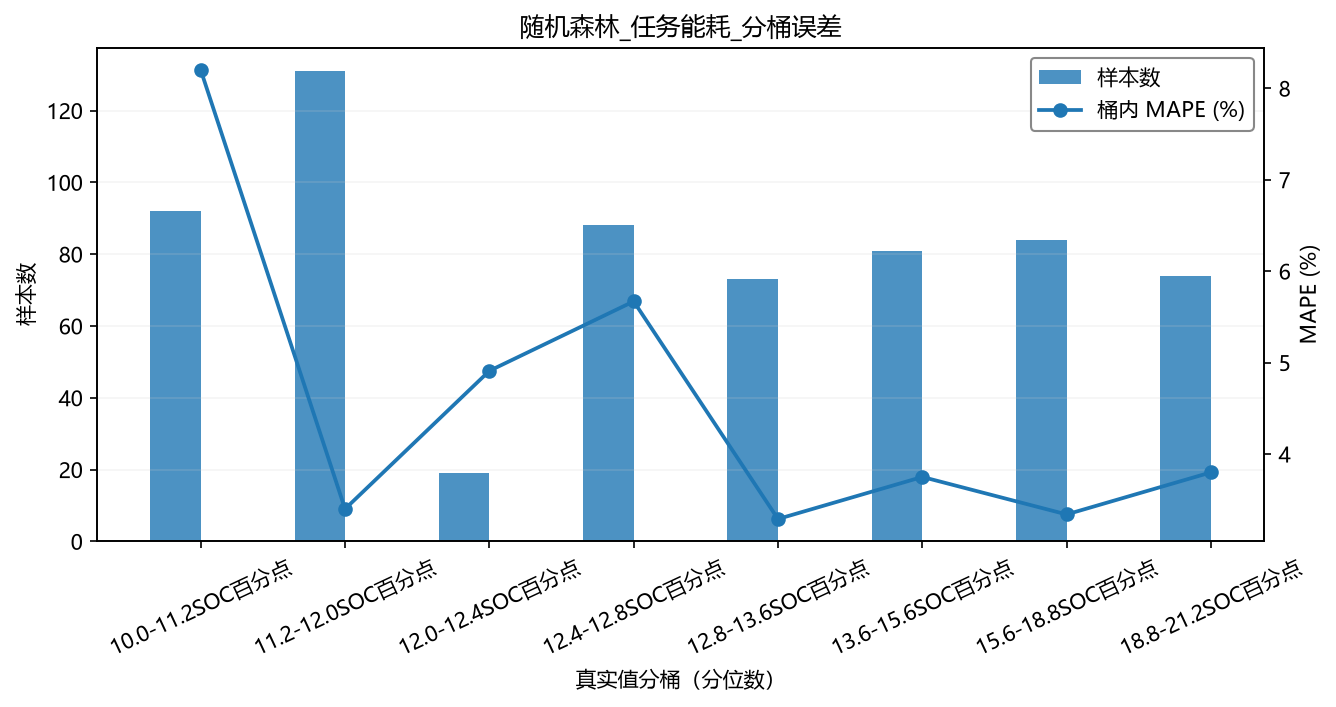

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\随机森林_任务能耗_分桶误差.png


In [48]:
# 默认全部绘制：5 个模型 × 2 个目标 × 5 类图 = 50 张图。
# 若只想画部分模型，可把下面列表改为例如 ["XGBoost", "LightGBM"]。
DETAIL_PLOT_MODELS = list(model_results.keys())

for model_name in DETAIL_PLOT_MODELS:
    print("\n" + "=" * 90)
    print("绘图：", model_name)
    plot_one_model_tabm_style(model_name, model_results[model_name])

## 15. 模型横向对比图

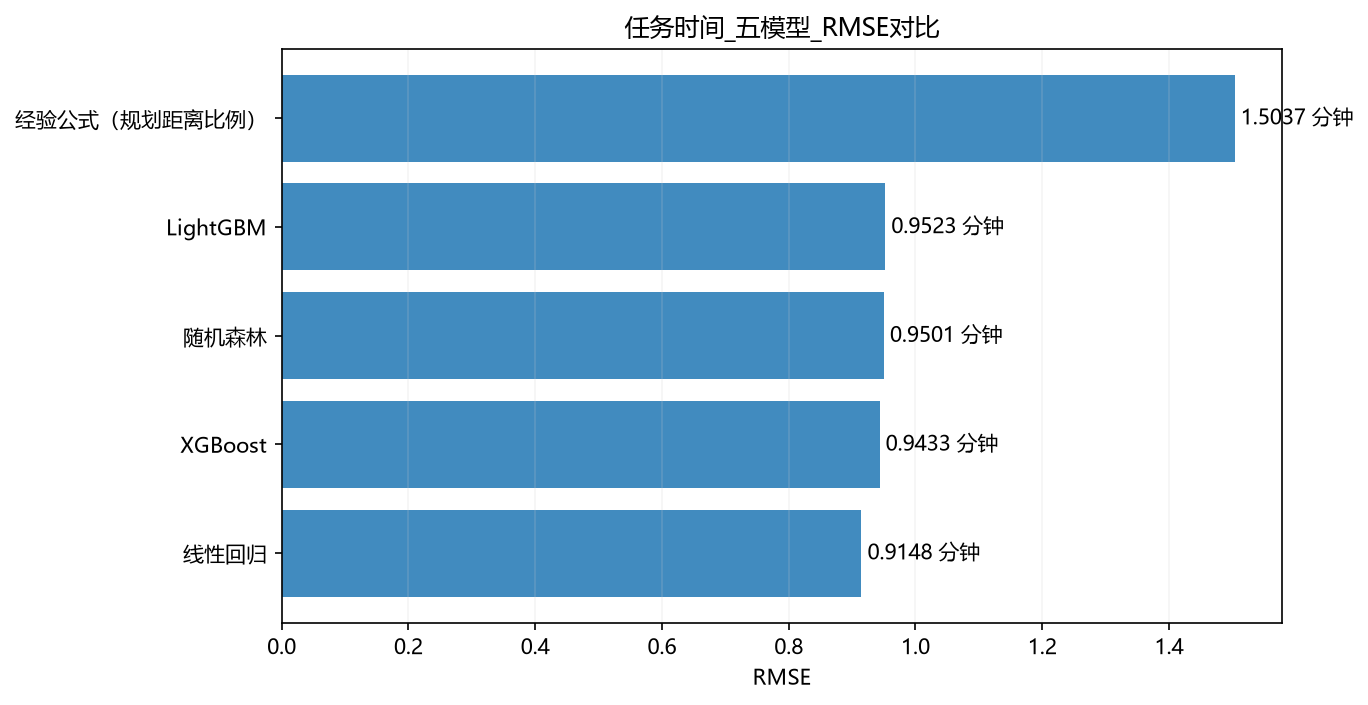

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\任务时间_五模型_RMSE对比.png


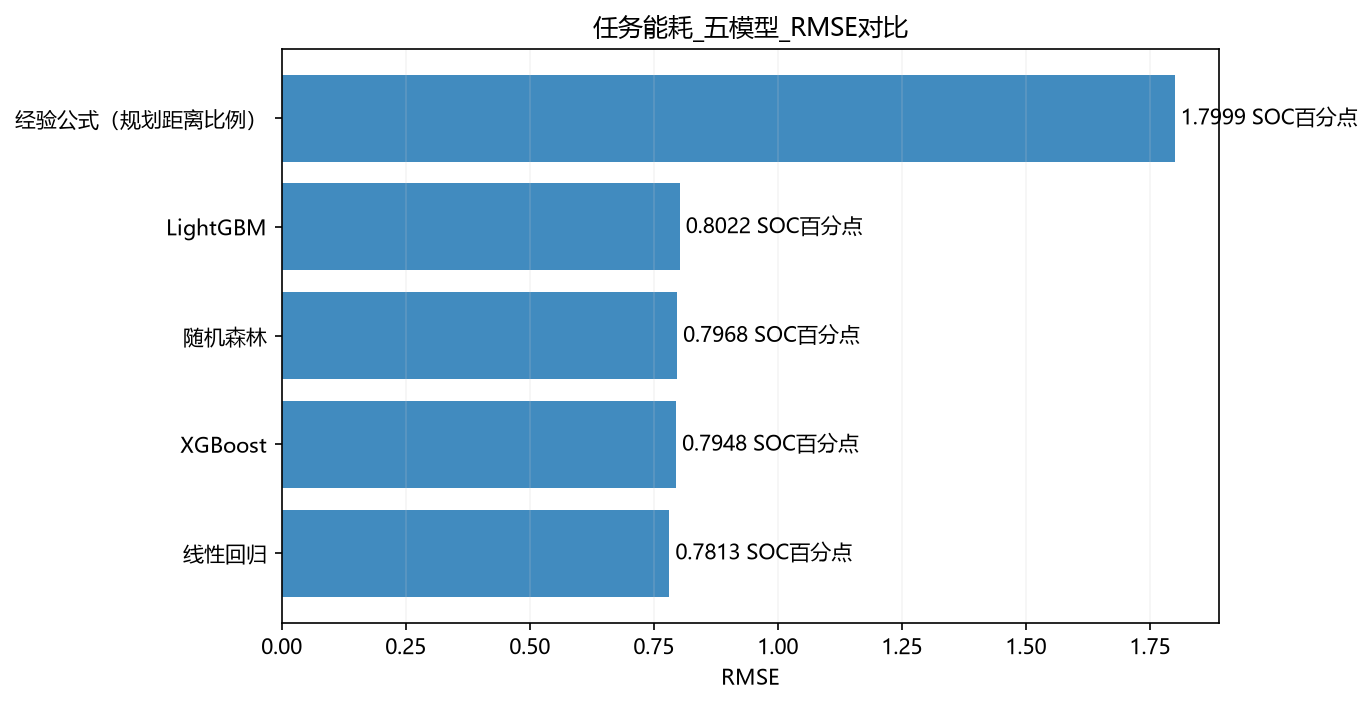

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\任务能耗_五模型_RMSE对比.png


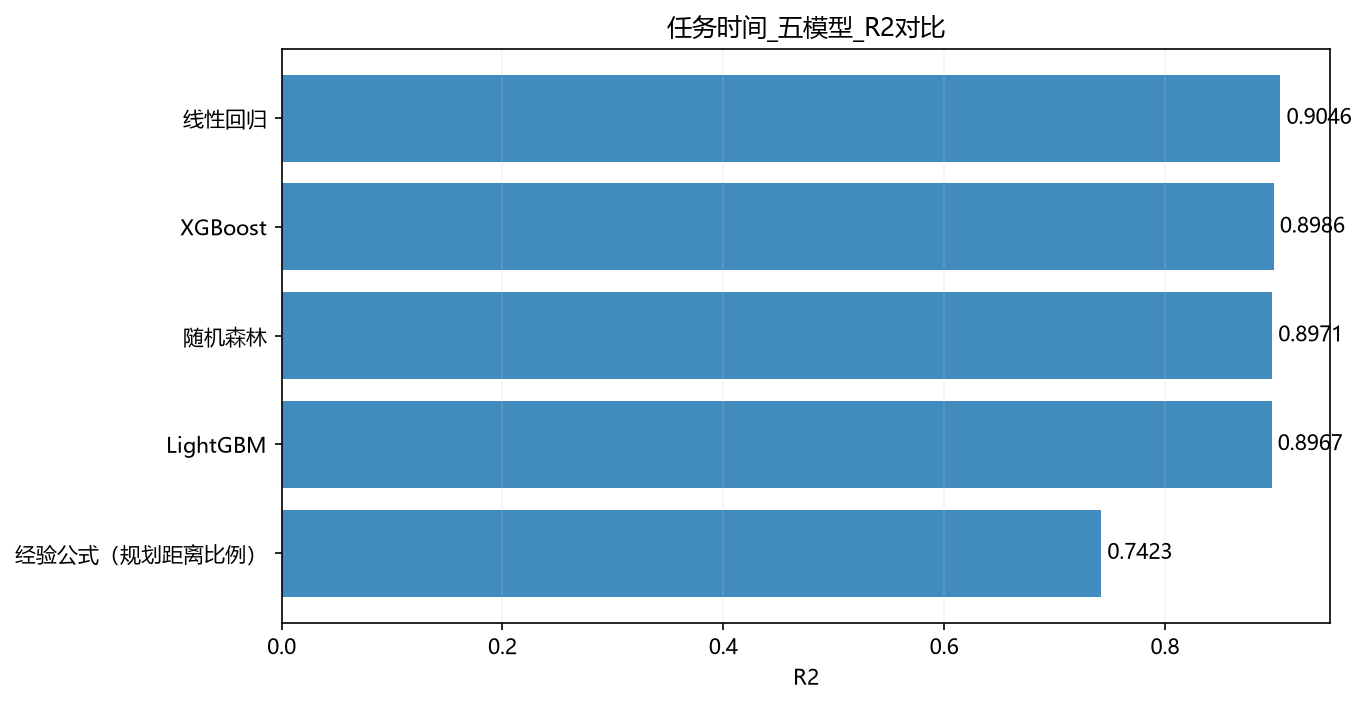

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\任务时间_五模型_R2对比.png


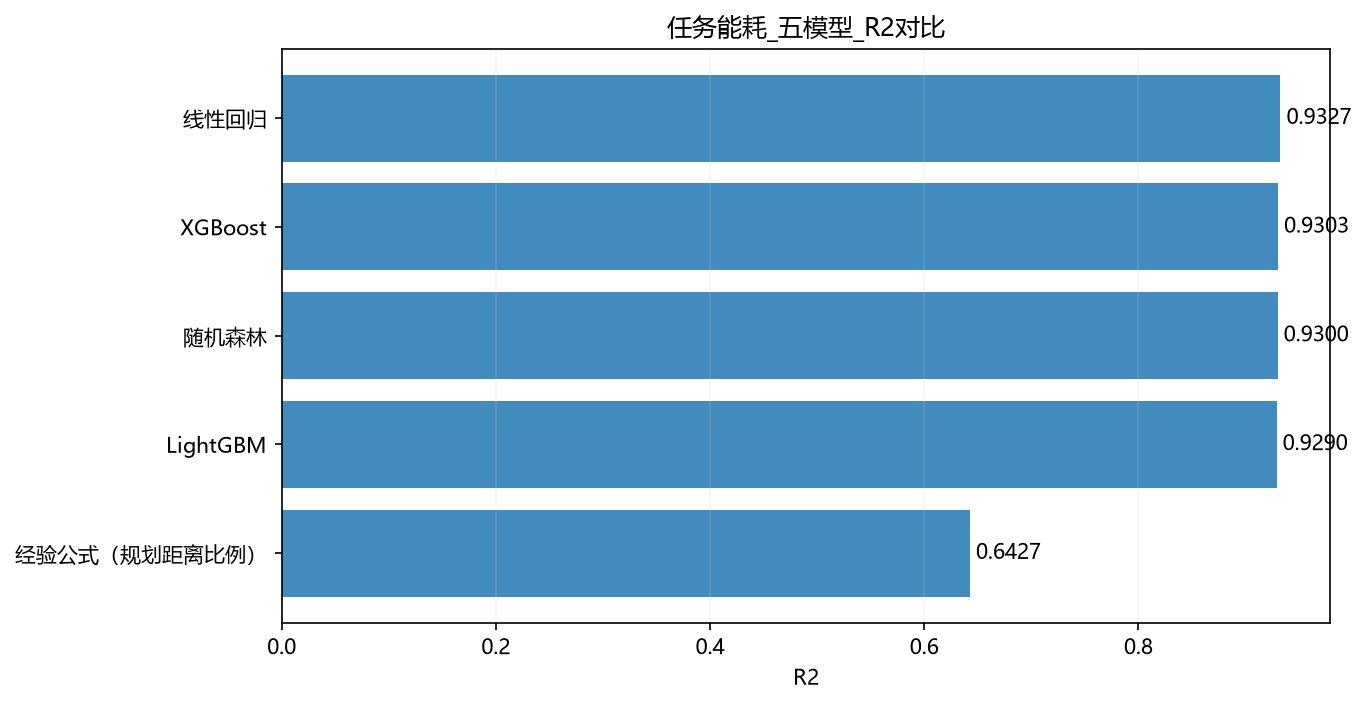

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\任务能耗_五模型_R2对比.png


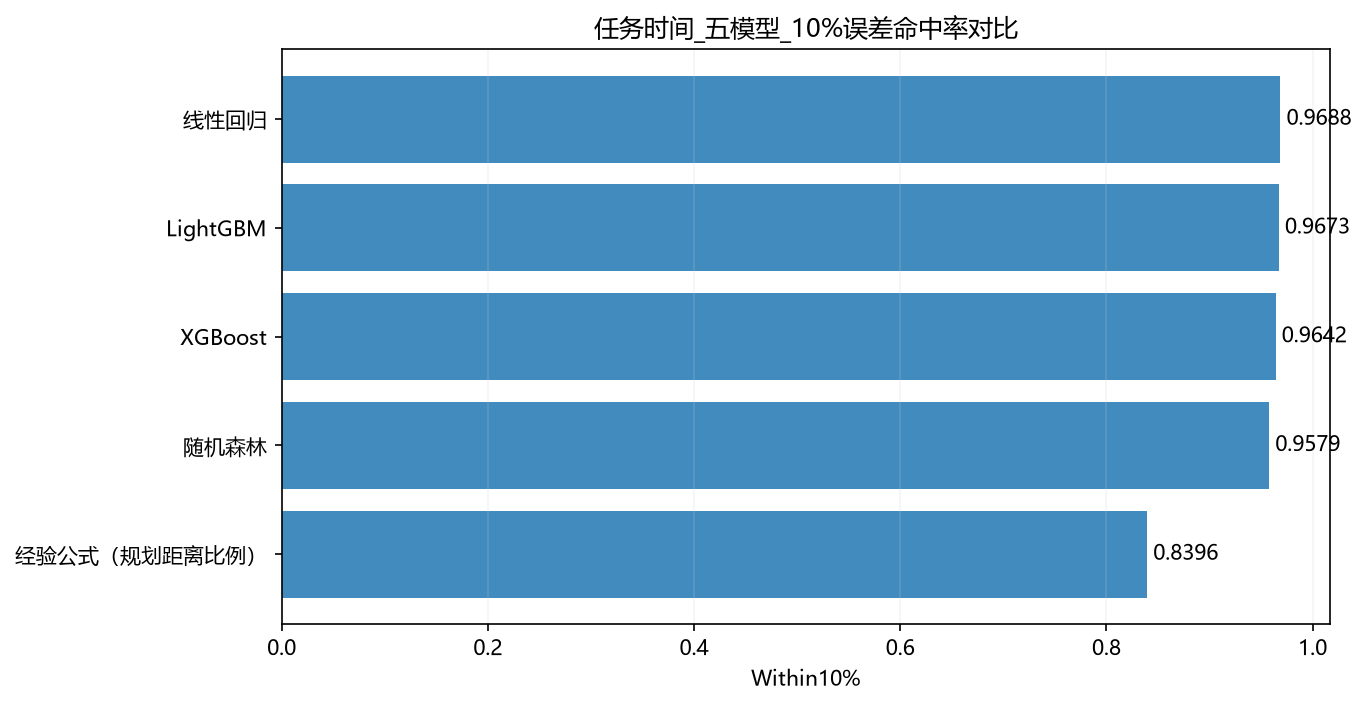

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\任务时间_五模型_10_误差命中率对比.png


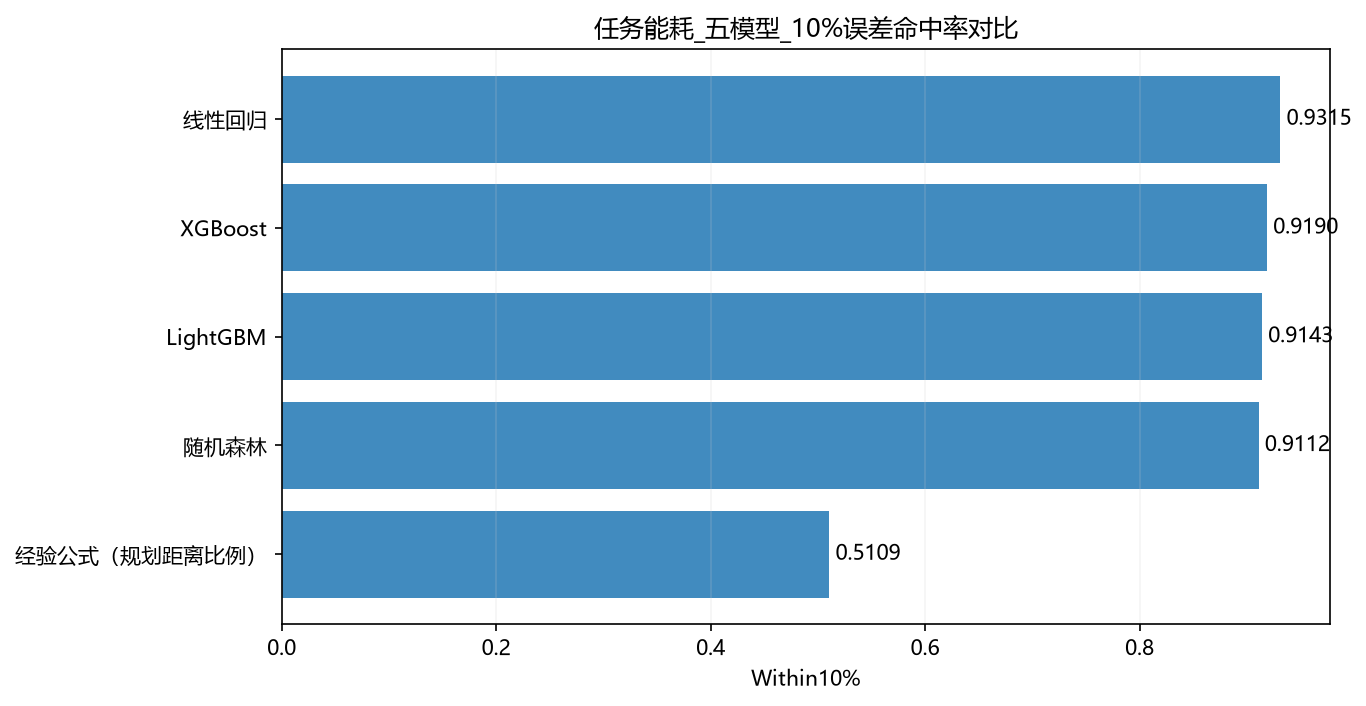

已保存： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots\任务能耗_五模型_10_误差命中率对比.png


In [49]:
def plot_model_metric(comparison_df, metric, title, unit_suffix=""):
    plot_df = comparison_df.sort_values(metric, ascending=True).copy()
    fig_height = max(4.8, 0.65 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(9.2, fig_height))
    bars = ax.barh(plot_df.index, plot_df[metric], alpha=0.85)

    for bar, value in zip(bars, plot_df[metric].to_numpy(dtype=float)):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {value:.4f}{unit_suffix}",
            va="center",
        )

    ax.set_xlabel(metric)
    ax.set_ylabel("")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


plot_model_metric(time_comparison, "RMSE", "任务时间_五模型_RMSE对比", " 分钟")
plot_model_metric(energy_comparison, "RMSE", "任务能耗_五模型_RMSE对比", " SOC百分点")
plot_model_metric(time_comparison, "R2", "任务时间_五模型_R2对比")
plot_model_metric(energy_comparison, "R2", "任务能耗_五模型_R2对比")
plot_model_metric(time_comparison, "Within10%", "任务时间_五模型_10%误差命中率对比")
plot_model_metric(energy_comparison, "Within10%", "任务能耗_五模型_10%误差命中率对比")

## 16. 查看逐条测试集预测

In [50]:
def safe_model_key(model_name: str) -> str:
    replacements = {
        "经验公式（规划距离比例）": "baseline",
        "线性回归": "linear",
        "XGBoost": "xgboost",
        "LightGBM": "lightgbm",
        "随机森林": "random_forest",
    }
    return replacements.get(model_name, re.sub(r"\W+", "_", model_name).strip("_").lower())


time_meta_cols = [
    col for col in ["task_id", "sn", "transport_device_id", "actual_start_time", "actual_end_time"]
    if col in time_test_df.columns
]
energy_meta_cols = [
    col for col in ["task_id", "sn", "transport_device_id", "actual_start_time", "actual_end_time"]
    if col in energy_test_df.columns
]

time_prediction_result = time_test_df[time_meta_cols + [TIME_TARGET]].copy()
energy_prediction_result = energy_test_df[energy_meta_cols + [ENERGY_TARGET]].copy()

for model_name, result in model_results.items():
    key = safe_model_key(model_name)

    time_prediction_result[f"{key}_pred"] = result["time_pred"]
    time_prediction_result[f"{key}_residual"] = (
        time_prediction_result[TIME_TARGET] - time_prediction_result[f"{key}_pred"]
    )
    time_prediction_result[f"{key}_abs_error"] = time_prediction_result[f"{key}_residual"].abs()

    energy_prediction_result[f"{key}_pred"] = result["energy_pred"]
    energy_prediction_result[f"{key}_residual"] = (
        energy_prediction_result[ENERGY_TARGET] - energy_prediction_result[f"{key}_pred"]
    )
    energy_prediction_result[f"{key}_abs_error"] = energy_prediction_result[f"{key}_residual"].abs()

print("任务时间逐条预测：")
display(time_prediction_result.head(10))

print("任务能耗逐条预测：")
display(energy_prediction_result.head(10))

best_time_key = safe_model_key(time_comparison.index[0])
best_energy_key = safe_model_key(energy_comparison.index[0])

print("任务时间最佳模型误差最大的 20 条：")
display(
    time_prediction_result
    .sort_values(f"{best_time_key}_abs_error", ascending=False)
    .head(20)
)

print("任务能耗最佳模型误差最大的 20 条：")
display(
    energy_prediction_result
    .sort_values(f"{best_energy_key}_abs_error", ascending=False)
    .head(20)
)

任务时间逐条预测：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,task_duration_min,baseline_pred,baseline_residual,baseline_abs_error,linear_pred,linear_residual,linear_abs_error,xgboost_pred,xgboost_residual,xgboost_abs_error,lightgbm_pred,lightgbm_residual,lightgbm_abs_error,random_forest_pred,random_forest_residual,random_forest_abs_error
2568,8098350477672705,TLE00860VR1450004,55374396682433,2026-07-04 06:51:01.122,2026-07-04 07:09:08.121,16.650533,18.555781,-1.905247,1.905247,17.375082,-0.724549,0.724549,17.119129,-0.468596,0.468596,16.892908,-0.242375,0.242375,17.117262,-0.466729,0.466729
2569,8098351104459009,TLE00860ER1450011,55396048724897,2026-07-04 06:51:39.041,2026-07-04 07:14:59.047,22.167617,22.113643,0.053974,0.053974,22.336088,-0.168472,0.168472,22.329470,-0.161853,0.161853,22.231834,-0.064217,0.064217,22.605936,-0.438320,0.438320
2570,8098354432672001,TLE00900AR1450052,55537321185345,2026-07-04 06:55:02.040,2026-07-04 07:14:19.037,17.333767,18.862292,-1.528526,1.528526,17.924845,-0.591078,0.591078,17.727760,-0.393994,0.393994,18.108274,-0.774508,0.774508,18.448282,-1.114516,1.114516
2571,8098357441855745,TLE00900JR1450046,55564861582721,2026-07-04 06:58:06.132,2026-07-04 07:20:05.141,19.316650,17.476723,1.839927,1.839927,18.860995,0.455655,0.455655,18.902311,0.414339,0.414339,18.701079,0.615571,0.615571,18.778055,0.538595,0.538595
2572,8098372112351489,TLE00900AR1450049,55564866228833,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,18.066500,17.471804,0.594696,0.594696,18.852926,-0.786426,0.786426,18.950382,-0.883882,0.883882,18.859622,-0.793122,0.793122,18.739863,-0.673363,0.673363
2573,8098382832042241,TLE00900CR1450050,55564868388833,2026-07-04 07:23:55.193,2026-07-04 07:48:05.000,22.426233,22.204340,0.221893,0.221893,22.469411,-0.043178,0.043178,22.428051,-0.001818,0.001818,22.405730,0.020504,0.020504,22.409132,0.017102,0.017102
2574,8098386453381377,TLE00860CR1450020,55396116151937,2026-07-04 07:27:36.036,2026-07-04 07:51:04.042,19.099400,17.547459,1.551941,1.551941,18.925545,0.173855,0.173855,18.916641,0.182759,0.182759,18.769942,0.329458,0.329458,18.863591,0.235809,0.235809
2575,8098389561934081,TLE00860VR1450004,55374396682433,2026-07-04 07:30:46.127,2026-07-04 07:51:12.115,18.933017,17.805539,1.127477,1.127477,19.780435,-0.847418,0.847418,19.900232,-0.967216,0.967216,19.946269,-1.013252,1.013252,19.850348,-0.917332,0.917332
2576,8098398408376577,TLE00900AR1450052,55537321185345,2026-07-04 07:39:46.037,2026-07-04 07:58:54.034,17.233667,17.347796,-0.114129,0.114129,17.444244,-0.210577,0.210577,17.546366,-0.312699,0.312699,17.695001,-0.461334,0.461334,17.658419,-0.424752,0.424752
2577,8098446608892161,TLE00900JR1450046,55564861582721,2026-07-04 08:28:48.143,2026-07-04 08:46:37.143,16.716383,17.138523,-0.422140,0.422140,17.177670,-0.461287,0.461287,17.228868,-0.512485,0.512485,16.915526,-0.199143,0.199143,17.207147,-0.490763,0.490763


任务能耗逐条预测：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,total_energy_soc_delta_pct,baseline_pred,baseline_residual,baseline_abs_error,linear_pred,linear_residual,linear_abs_error,xgboost_pred,xgboost_residual,xgboost_abs_error,lightgbm_pred,lightgbm_residual,lightgbm_abs_error,random_forest_pred,random_forest_residual,random_forest_abs_error
2568,8098350477672705,TLE00860VR1450004,55374396682433,2026-07-04 06:51:01.122,2026-07-04 07:09:08.121,13.2,14.959577,-1.759577,1.759577,13.442391,-0.242391,0.242391,13.543794,-0.343794,0.343794,13.558641,-0.358641,0.358641,13.747222,-0.547222,0.547222
2569,8098351104459009,TLE00860ER1450011,55396048724897,2026-07-04 06:51:39.041,2026-07-04 07:14:59.047,18.4,17.827908,0.572092,0.572092,18.997544,-0.597544,0.597544,19.266973,-0.866973,0.866973,19.337644,-0.937644,0.937644,19.352000,-0.952000,0.952000
2570,8098354432672001,TLE00900AR1450052,55537321185345,2026-07-04 06:55:02.040,2026-07-04 07:14:19.037,13.6,15.206685,-1.606685,1.606685,13.236683,0.363317,0.363317,13.274455,0.325545,0.325545,13.634132,-0.034132,0.034132,13.491263,0.108737,0.108737
2571,8098357441855745,TLE00900JR1450046,55564861582721,2026-07-04 06:58:06.132,2026-07-04 07:20:05.141,14.0,14.089646,-0.089646,0.089646,13.946843,0.053157,0.053157,13.802654,0.197346,0.197346,13.678017,0.321983,0.321983,13.679881,0.320119,0.320119
2572,8098372112351489,TLE00900AR1450049,55564866228833,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,11.2,14.085680,-2.885680,2.885680,14.010811,-2.810811,2.810811,14.265504,-3.065504,3.065504,13.888167,-2.688167,2.688167,13.597498,-2.397498,2.397498
2573,8098382832042241,TLE00900CR1450050,55564868388833,2026-07-04 07:23:55.193,2026-07-04 07:48:05.000,19.6,17.901028,1.698972,1.698972,18.862923,0.737077,0.737077,19.034407,0.565593,0.565593,18.717016,0.882984,0.882984,18.909733,0.690267,0.690267
2574,8098386453381377,TLE00860CR1450020,55396116151937,2026-07-04 07:27:36.036,2026-07-04 07:51:04.042,12.4,14.146673,-1.746673,1.746673,13.911243,-1.511243,1.511243,13.567598,-1.167598,1.167598,13.172528,-0.772528,0.772528,13.357001,-0.957001,0.957001
2575,8098389561934081,TLE00860VR1450004,55374396682433,2026-07-04 07:30:46.127,2026-07-04 07:51:12.115,12.8,14.354737,-1.554737,1.554737,14.205578,-1.405578,1.405578,14.135100,-1.335100,1.335100,14.033484,-1.233484,1.233484,14.150667,-1.350667,1.350667
2576,8098398408376577,TLE00900AR1450052,55537321185345,2026-07-04 07:39:46.037,2026-07-04 07:58:54.034,12.0,13.985706,-1.985706,1.985706,11.847592,0.152408,0.152408,11.911568,0.088432,0.088432,12.368022,-0.368022,0.368022,11.941166,0.058834,0.058834
2577,8098446608892161,TLE00900JR1450046,55564861582721,2026-07-04 08:28:48.143,2026-07-04 08:46:37.143,12.0,13.816991,-1.816991,1.816991,11.764425,0.235575,0.235575,11.629965,0.370035,0.370035,11.731702,0.268298,0.268298,11.758260,0.241740,0.241740


任务时间最佳模型误差最大的 20 条：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,task_duration_min,baseline_pred,baseline_residual,baseline_abs_error,linear_pred,linear_residual,linear_abs_error,xgboost_pred,xgboost_residual,xgboost_abs_error,lightgbm_pred,lightgbm_residual,lightgbm_abs_error,random_forest_pred,random_forest_residual,random_forest_abs_error
2923,8101229803258113,TLE00900AR1450052,55537321185345,2026-07-06 07:39:59.114,2026-07-06 08:14:15.129,30.883283,20.088088,10.795196,10.795196,21.279148,9.604135,9.604135,21.589039,9.294244,9.294244,21.768601,9.114682,9.114682,21.730003,9.153280,9.153280
2924,8101232387588353,TLE00860VR1450018,55396247774017,2026-07-06 07:42:37.144,2026-07-06 08:07:41.152,23.783467,16.447042,7.336425,7.336425,15.306864,8.476602,8.476602,15.523993,8.259473,8.259473,15.567440,8.216026,8.216026,15.582316,8.201151,8.201151
2925,8101236806615297,TLE00900JR1450046,55564861582721,2026-07-06 07:47:07.136,2026-07-06 08:15:57.137,26.783367,17.779841,9.003525,9.003525,19.026890,7.756477,7.756477,19.021267,7.762100,7.762100,19.047611,7.735755,7.735755,18.957315,7.826051,7.826051
2926,8101237699297537,TLE00860CR1450020,55396116151937,2026-07-06 07:48:01.178,2026-07-06 08:12:29.178,23.483850,16.526687,6.957163,6.957163,16.837060,6.646790,6.646790,17.129314,6.354536,6.354536,17.274708,6.209142,6.209142,17.313196,6.170654,6.170654
2932,8101329709564161,TLE00900CR1450050,55564868388833,2026-07-06 09:21:37.201,2026-07-06 09:48:53.196,23.503267,19.264900,4.238366,4.238366,21.082654,2.420612,2.420612,21.311605,2.191661,2.191661,21.476755,2.026512,2.026512,21.615603,1.887664,1.887664
2809,8100183334060289,TLE00900AR1450052,55537321185345,2026-07-05 13:55:29.033,2026-07-05 14:20:43.039,18.949833,16.945977,2.003857,2.003857,16.607746,2.342087,2.342087,17.013212,1.936621,1.936621,17.001042,1.948792,1.948792,17.165152,1.784681,1.784681
2850,8100527576875265,TLE00900JR1450046,55564861582721,2026-07-05 19:45:39.136,2026-07-05 20:09:24.138,22.117733,17.957605,4.160129,4.160129,19.857780,2.259953,2.259953,19.869528,2.248206,2.248206,20.097990,2.019743,2.019743,20.073349,2.044384,2.044384
2668,8099034542899457,TLE00900VR1450048,55564864593345,2026-07-04 18:26:53.054,2026-07-04 18:44:38.058,14.299183,20.570222,-6.271039,6.271039,16.374758,-2.075575,2.075575,16.892570,-2.593387,2.593387,16.818696,-2.519513,2.519513,16.518050,-2.218867,2.218867
2588,8098518135030017,TLE00860VR1450018,55396247774017,2026-07-04 09:41:34.009,2026-07-04 10:01:16.010,17.657367,16.395010,1.262357,1.262357,15.652596,2.004771,2.004771,15.767689,1.889678,1.889678,15.784144,1.873223,1.873223,15.821460,1.835907,1.835907
2580,8098473543319809,TLE00900CR1450050,55564868388833,2026-07-04 08:56:12.197,2026-07-04 09:17:05.000,17.443217,16.336944,1.106273,1.106273,15.461938,1.981279,1.981279,15.915853,1.527364,1.527364,15.854826,1.588391,1.588391,15.686998,1.756218,1.756218


任务能耗最佳模型误差最大的 20 条：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,total_energy_soc_delta_pct,baseline_pred,baseline_residual,baseline_abs_error,linear_pred,linear_residual,linear_abs_error,xgboost_pred,xgboost_residual,xgboost_abs_error,lightgbm_pred,lightgbm_residual,lightgbm_abs_error,random_forest_pred,random_forest_residual,random_forest_abs_error
2949,8101444423762177,TLE00860HR1450010,55375199115009,2026-07-06 11:18:19.199,2026-07-06 11:39:07.003,10.0,13.993755,-3.993755,3.993755,13.671002,-3.671002,3.671002,13.846733,-3.846733,3.846733,13.062981,-3.062981,3.062981,14.428000,-4.428000,4.428000
2945,8101411424993537,TLE00900VR1450048,55564864593345,2026-07-06 10:44:45.078,2026-07-06 11:04:46.083,10.8,14.040001,-3.240001,3.240001,13.826441,-3.026441,3.026441,14.574288,-3.774288,3.774288,14.779969,-3.979969,3.979969,15.036000,-4.236000,4.236000
2882,8100820658290945,TLE00860VR1450004,55374396682433,2026-07-06 00:43:47.126,2026-07-06 01:05:35.130,11.6,14.565140,-2.965140,2.965140,14.441516,-2.841516,2.841516,14.014797,-2.414797,2.414797,14.135539,-2.535539,2.535539,14.399574,-2.799574,2.799574
2572,8098372112351489,TLE00900AR1450049,55564866228833,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,11.2,14.085680,-2.885680,2.885680,14.010811,-2.810811,2.810811,14.265504,-3.065504,3.065504,13.888167,-2.688167,2.688167,13.597498,-2.397498,2.397498
2951,8101460724826369,TLE00900AR1450049,55564866228833,2026-07-06 11:34:54.030,2026-07-06 11:57:28.020,11.2,14.490329,-3.290329,3.290329,13.843038,-2.643038,2.643038,13.694744,-2.494744,2.494744,13.577290,-2.377290,2.377290,13.505756,-2.305756,2.305756
2953,8101477346984193,TLE00860VR1450004,55374396682433,2026-07-06 11:51:48.091,2026-07-06 12:13:35.097,11.6,14.495145,-2.895145,2.895145,14.108772,-2.508772,2.508772,14.123004,-2.523004,2.523004,13.951682,-2.351682,2.351682,13.946196,-2.346196,2.346196
3156,8103049029632257,TLE00860VR1450018,55396247774017,2026-07-07 14:30:35.100,2026-07-07 14:54:29.091,21.2,16.403734,4.796266,4.796266,18.771411,2.428589,2.428589,18.540497,2.659503,2.659503,18.783337,2.416663,2.416663,18.868800,2.331200,2.331200
3090,8102522294976769,TLE00860HR1450010,55375199115009,2026-07-07 05:34:46.171,2026-07-07 05:53:28.160,15.2,13.892862,1.307138,1.307138,12.982921,2.217079,2.217079,13.373746,1.826254,1.826254,13.134937,2.065063,2.065063,13.171177,2.028823,2.028823
3208,8103537125081345,TLE00900JR1450046,55564861582721,2026-07-07 22:47:06.153,2026-07-07 23:12:36.166,20.8,16.977658,3.822342,3.822342,18.667719,2.132281,2.132281,19.254066,1.545934,1.545934,19.121551,1.678449,1.678449,18.940000,1.860000,1.860000
2869,8100714389405953,TLE00860VR1450018,55396247774017,2026-07-05 22:55:42.149,2026-07-05 23:20:09.187,12.0,14.282777,-2.282777,2.282777,14.094291,-2.094291,2.094291,13.746086,-1.746086,1.746086,13.603024,-1.603024,1.603024,13.721533,-1.721533,1.721533


## 17. 保存模型、固定参数、指标、预测和运行元数据

In [51]:
# 1. 指标与逐条预测
time_comparison.to_csv(
    OUTPUT_DIR / "time_test_metrics.csv",
    encoding="utf-8-sig",
)
energy_comparison.to_csv(
    OUTPUT_DIR / "energy_test_metrics.csv",
    encoding="utf-8-sig",
)
time_prediction_result.to_csv(
    OUTPUT_DIR / "time_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
energy_prediction_result.to_csv(
    OUTPUT_DIR / "energy_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

# 2. 经验公式系数
baseline_data = {
    "distance_feature": "planned_total_distance_m",
    "time_coefficient_min_per_m": baseline_time_k,
    "energy_coefficient_soc_pct_per_m": baseline_energy_k,
}
with (OUTPUT_DIR / "empirical_formula_coefficients.json").open("w", encoding="utf-8") as file:
    json.dump(baseline_data, file, ensure_ascii=False, indent=2)

# 3. 固定超参数
with (OUTPUT_DIR / "fixed_hyperparameters.json").open("w", encoding="utf-8") as file:
    json.dump(FIXED_HYPERPARAMS, file, ensure_ascii=False, indent=2)

# 4. 保存四类可训练模型；每个文件中同时包含时间和能耗模型及各自特征列。
if SAVE_MODELS:
    for model_name in ["线性回归", "XGBoost", "LightGBM", "随机森林"]:
        result = model_results[model_name]
        key = safe_model_key(model_name)
        joblib.dump(
            {
                "model_name": model_name,
                "time_model": result["time_model"],
                "energy_model": result["energy_model"],
                "time_feature_columns": TIME_FEATURE_COLS,
                "energy_feature_columns": ENERGY_FEATURE_COLS,
                "time_target": TIME_TARGET,
                "energy_target": ENERGY_TARGET,
                "fixed_hyperparameters": FIXED_HYPERPARAMS[model_name],
                "prediction_postprocess": "np.maximum(prediction, 0.0)",
            },
            OUTPUT_DIR / f"{key}_time_energy_models.joblib",
        )

# 5. 运行元数据
metadata = {
    "data_file": str(DATA_FILE),
    "output_dir": str(OUTPUT_DIR),
    "base_sample_count": int(len(df)),
    "time_sample_count": int(len(time_df)),
    "energy_sample_count": int(len(energy_df)),
    "time_train_count": int(len(time_train_df)),
    "time_test_count": int(len(time_test_df)),
    "energy_train_count": int(len(energy_train_df)),
    "energy_test_count": int(len(energy_test_df)),
    "time_feature_columns": TIME_FEATURE_COLS,
    "energy_feature_columns": ENERGY_FEATURE_COLS,
    "time_target": TIME_TARGET,
    "energy_target": ENERGY_TARGET,
    "test_size": TEST_SIZE,
    "fixed_hyperparameters": FIXED_HYPERPARAMS,
    "time_best_model": str(time_comparison.index[0]),
    "energy_best_model": str(energy_comparison.index[0]),
    "time_metrics": time_comparison.reset_index().to_dict(orient="records"),
    "energy_metrics": energy_comparison.reset_index().to_dict(orient="records"),
}
with (OUTPUT_DIR / "run_metadata.json").open("w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

print("全部结果已保存到：", OUTPUT_DIR.resolve())
print("图表目录：", PLOT_DIR.resolve())

全部结果已保存到： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams
图表目录： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\PreTaskModels_TabMFeatures_FixedParams\plots


## 18. 输出文件

运行完成后，`OUTPUT_DIR` 中包括：

- `time_test_metrics.csv`：五种方法的任务时间 MAE / RMSE / R² / Within10%；
- `energy_test_metrics.csv`：五种方法的任务能耗指标；
- `time_test_predictions.csv`、`energy_test_predictions.csv`：逐条真实值、预测值、残差、绝对误差；
- `empirical_formula_coefficients.json`：经验公式的时间/能耗距离比例系数；
- `fixed_hyperparameters.json`：XGBoost、LightGBM、随机森林等本次直接使用的固定参数；
- `linear_time_energy_models.joblib`、`xgboost_time_energy_models.joblib`、`lightgbm_time_energy_models.joblib`、`random_forest_time_energy_models.joblib`：训练好的两目标模型；
- `run_metadata.json`：样本量、特征列、指标和最优模型摘要；
- `plots/`：五个模型的 TabM 风格详细图，以及模型横向对比图。

### 与原“事先预测模型”的不同

- 不再让时间和能耗共用同一套输入；
- 不再运行网格搜索；
- 不包含“线性回归 + XGBoost 残差”和 HGBR；
- 不再依赖旧版 `CORE_FEATURE_COLS`，而是直接使用 TabM 当前 14 个时间特征和 14 个能耗特征；
- 数据清洗、时间切分、非负截断、指标和绘图尽量与 TabM 对齐。